# Seeded LC vs BCO on Mumford0

This notebook mirrors `evaluation.ipynb`, but focuses on a seeded-construction scenario:

1. Run a baseline LC pass on `Mumford0`.
2. Revisit those routes in a second LC pass so they are not treated as finished, with `n_routes + 1` and `max_route_len + 3`.
3. Run BCO from the same seeded LC network and compare the metrics.


## 1. Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
from torch_geometric.loader import DataLoader

from connectpt.routes_generator.citygraph_dataset import get_dataset_from_config
from connectpt.routes_generator.utils import get_eval_cfg
from connectpt.routes_generator.eval_route_generator import eval_model
from connectpt.routes_generator.bee_colony import bee_colony
from connectpt.routes_generator.torch_utils import dump_routes, get_batch_tensor_from_routes
import connectpt.routes_generator.utils as lrnu

## 2. Paths And Experiment Parameters

In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "connectpt").exists() and (candidate / "examples").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root from current working directory")

ROOT_DIR = find_repo_root()
CFG_DIR = ROOT_DIR / "connectpt" / "routes_generator" / "cfg"
BENCHMARK_DIR = ROOT_DIR / "examples" / "data" / "benchmark"
MODEL_WEIGHTS_PATH = ROOT_DIR / "examples" / "data" / "model_weights" / "inductive_random_graphs_weighted_connectivity.pt"
EDIT_MODEL_WEIGHTS_PATH = ROOT_DIR / "examples" / "route_generator" / "lc_improvement_outputs" / "improvement_lc_improvement_trim.pt"
OUTPUT_ROUTES_DIR = ROOT_DIR / "examples" / "route_generator" / "output_routes"

CITY_NAME = "Mumford0"

BASE_N_ROUTES = 10
BASE_MIN_ROUTE_LEN = 2
BASE_MAX_ROUTE_LEN = 3

SEEDED_N_ROUTES = BASE_N_ROUTES
SEEDED_MIN_ROUTE_LEN = BASE_MIN_ROUTE_LEN
SEEDED_MAX_ROUTE_LEN = BASE_MAX_ROUTE_LEN + 10

LC_SAMPLES = 100
USE_NEURAL_BCO = False
BCO_N_BEES = 10
BCO_N_ITERATIONS = 20
BCO_N_TYPE1_BEES = 5
BCO_TYPE4_IGNORE_MAX_ROUTE_LEN = True  # set True to let type4 ignore eval.max_route_len
BCO_TYPE5_IGNORE_MAX_ROUTE_LEN = True  # set True to let type5 (extend+trim agent) ignore eval.max_route_len
BCO_TYPE6_IGNORE_MAX_ROUTE_LEN = True  # set True to let type6 (trim-only agent) ignore eval.max_route_len

DEMAND_TIME_WEIGHT = 0.33
ROUTE_TIME_WEIGHT = 0.33
MEDIAN_CONNECTIVITY_WEIGHT = 0.33   

print(f"ROOT_DIR: {ROOT_DIR}")
print(f"CFG_DIR: {CFG_DIR}")
print(f"MODEL_WEIGHTS_PATH exists: {MODEL_WEIGHTS_PATH.exists()}")
print(f"EDIT_MODEL_WEIGHTS_PATH exists: {EDIT_MODEL_WEIGHTS_PATH.exists()}")

ROOT_DIR: D:\PythonProjects\connectpt
CFG_DIR: D:\PythonProjects\connectpt\connectpt\routes_generator\cfg
MODEL_WEIGHTS_PATH exists: True
EDIT_MODEL_WEIGHTS_PATH exists: True


## 3. Load Benchmark Tensors

In [3]:
def load_benchmark_tensors(city_name: str = CITY_NAME) -> dict:
    node_locs = torch.tensor(
        np.genfromtxt(BENCHMARK_DIR / f"{city_name}Coords.txt", skip_header=1),
        dtype=torch.float32,
    )
    street_adj = torch.tensor(
        np.genfromtxt(BENCHMARK_DIR / f"{city_name}TravelTimes.txt"),
        dtype=torch.float32,
    ) * 60
    demand = torch.tensor(
        np.genfromtxt(BENCHMARK_DIR / f"{city_name}Demand.txt"),
        dtype=torch.float32,
    )
    return {
        "node_locs": node_locs,
        "street_adj": street_adj,
        "demand": demand,
    }

input_tensors = load_benchmark_tensors()
print({key: tuple(value.shape) for key, value in input_tensors.items()})


{'node_locs': (30, 2), 'street_adj': (30, 30), 'demand': (30, 30)}


## 4. Helper Functions

In [4]:
def make_test_dataloader(dataset_cfg):
    dataset = get_dataset_from_config(dataset_cfg, tensors=ensure_input_tensors())
    return DataLoader(dataset, batch_size=1)


BCO_ROUTE_SELECTION_MODES = {
    "uniform": {
        "label": "uniform random",
        "use_demand_weighted_route_selection": False,
    },
    "demand_weighted": {
        "label": "demand-weighted",
        "use_demand_weighted_route_selection": True,
    },
}


def route_selection_mode_label(mode_key: str) -> str:
    return BCO_ROUTE_SELECTION_MODES[mode_key]["label"]


def route_selection_mode_suffix(mode_key: str) -> str:
    return mode_key


def build_lc_cfg(run_name: str, n_routes: int, min_route_len: int, max_route_len: int):
    params = {
        "dataset_name": "tensor",
        "n_routes": n_routes,
        "min_route_len": min_route_len,
        "max_route_len": max_route_len,
        "demand_time_weight": DEMAND_TIME_WEIGHT,
        "route_time_weight": ROUTE_TIME_WEIGHT,
        "median_connectivity_weight": MEDIAN_CONNECTIVITY_WEIGHT,
        "run_name": run_name,
        "model_weights": str(MODEL_WEIGHTS_PATH),
    }
    cfg = get_eval_cfg(str(CFG_DIR), "eval_model_mumford", params)
    cfg.batch_size = 1
    return cfg


def build_bco_cfg(
    run_name: str,
    n_routes: int,
    min_route_len: int,
    max_route_len: int,
    use_neural_bees: bool = USE_NEURAL_BCO,
    n_bees: int = BCO_N_BEES,
    n_type1_bees: int = BCO_N_TYPE1_BEES,
    n_type2_bees: int | None = None,
    n_type4_bees: int = 0,
    n_type5_bees: int = 0,
    n_type6_bees: int = 0,
    ignore_type4_max_route_len: bool = BCO_TYPE4_IGNORE_MAX_ROUTE_LEN,
    ignore_type5_max_route_len: bool = BCO_TYPE5_IGNORE_MAX_ROUTE_LEN,
    ignore_type6_max_route_len: bool = BCO_TYPE6_IGNORE_MAX_ROUTE_LEN,
    use_demand_weighted_route_selection: bool = False,
):
    """Build a BCO config.

    Bee type assignment per modification step (out of BCO_N_BEES total):
      type1 - rebuild the chosen route (heuristic for classic BCO, neural for neural BCO)
      type2 - local extend/shorten by one stop
      type3 - random path-combiner rebuild (only if n_type1+n_type2+n_type4+n_type5+n_type6 < n_bees)
      type4 - single GNN step extension of the chosen route
      type5 - single edit step (extend / trim_start / trim_end / halt) using the LC improvement edit model
      type6 - trim-only edit step (trim_start / trim_end / halt) using the LC improvement edit model

    Route selection mode:
      uniform random   - choose the route slot uniformly
      demand-weighted  - sample route slots with probability proportional to
                         how poorly they directly serve demand
    """
    base_cfg_name = "neural_bco_mumford" if use_neural_bees else "bco_mumford"
    effective_type2 = (
        n_bees - n_type1_bees - n_type4_bees - n_type5_bees - n_type6_bees
        if n_type2_bees is None
        else n_type2_bees
    )
    overrides = [
        "+eval=mumford0",
        "++eval.dataset.type=tensor",
        f"++eval.n_routes={n_routes}",
        f"++eval.min_route_len={min_route_len}",
        f"++eval.max_route_len={max_route_len}",
        f"++experiment.cost_function.kwargs.demand_time_weight={DEMAND_TIME_WEIGHT}",
        f"++experiment.cost_function.kwargs.route_time_weight={ROUTE_TIME_WEIGHT}",
        f"++experiment.cost_function.kwargs.median_connectivity_weight={MEDIAN_CONNECTIVITY_WEIGHT}",
        f"++run_name={run_name}",
        f"++n_bees={n_bees}",
        f"++n_iterations={BCO_N_ITERATIONS}",
        f"++n_type1_bees={n_type1_bees}",
        f"++n_type2_bees={effective_type2}",
        f"++n_type4_bees={n_type4_bees}",
        f"++n_type5_bees={n_type5_bees}",
        f"++n_type6_bees={n_type6_bees}",
        f"++ignore_type4_max_route_len={str(ignore_type4_max_route_len).lower()}",
        f"++ignore_type5_max_route_len={str(ignore_type5_max_route_len).lower()}",
        f"++ignore_type6_max_route_len={str(ignore_type6_max_route_len).lower()}",
        f"++use_demand_weighted_route_selection={str(use_demand_weighted_route_selection).lower()}",
    ]
    if use_neural_bees:
        overrides.append(f"+model.weights={MODEL_WEIGHTS_PATH}")
    with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
        cfg = compose(config_name=base_cfg_name, overrides=overrides)
    cfg.batch_size = 1
    n_type3 = (n_bees - n_type1_bees - effective_type2 - n_type4_bees -
               n_type5_bees - n_type6_bees)
    route_selection_label = (
        "demand-weighted"
        if use_demand_weighted_route_selection
        else "uniform-random"
    )
    print(
        f"[{run_name}] route_selection={route_selection_label} | "
        f"bee split: type1={n_type1_bees} type2={effective_type2} "
        f"type3={n_type3} type4={n_type4_bees} "
        f"type5={n_type5_bees} type6={n_type6_bees}  "
        f"(total={n_bees})"
    )
    return cfg


def run_lc(cfg, init_routes=None, revisit_routes=None):
    dataloader = make_test_dataloader(cfg.eval.dataset)
    device, run_name, _, cost_obj, model = lrnu.process_standard_experiment_cfg(
        cfg,
        run_name_prefix="lc_",
        weights_required=True,
    )
    init_cfg = OmegaConf.create({"method": "tensor"}) if init_routes is not None else None
    if hasattr(model, "clear_step_counts_log"):
        model.clear_step_counts_log()
    _, unserved_demand, metrics, routes = eval_model(
        model,
        dataloader,
        cfg.eval,
        cost_obj,
        n_samples=LC_SAMPLES,
        return_routes=True,
        silent=True,
        device=device,
        init_cfg=init_cfg,
        routes_tensor=init_routes,
        revisit_routes_tensor=revisit_routes,
    )
    step_counts = getattr(model, "route_step_counts_log", [])
    return run_name, metrics, unserved_demand, routes, list(step_counts)


def build_edit_model(device):
    """Load the trim-capable edit model used by the type-5 BCO mutation."""
    with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
        edit_cfg = compose(
            config_name="ppo_50nodes.yaml",
            overrides=[
                "model=bestsofar_feb2023_trim",
                "model.route_generator.kwargs.serial_halting=True",
                "++run_name=eval_seeded_edit_model",
                "++experiment.logdir=null",
                f"+model.weights={EDIT_MODEL_WEIGHTS_PATH}",
            ],
        )
    edit_model = lrnu.build_model_from_cfg(edit_cfg.model, edit_cfg.experiment)
    edit_model.load_state_dict(
        torch.load(EDIT_MODEL_WEIGHTS_PATH, map_location=device)
    )
    edit_model.to(device).eval()
    return edit_model


def run_bco(cfg, init_routes, mutation_counts_out=None):
    dataloader = make_test_dataloader(cfg.eval.dataset)
    use_neural_bees = cfg.get("neural_bees", False)
    prefix = "neural_bco_" if use_neural_bees else "bco_"
    device, run_name, _, cost_obj, bee_model = lrnu.process_standard_experiment_cfg(
        cfg,
        run_name_prefix=prefix,
        weights_required=use_neural_bees,
    )
    force_linking_unlinked = cfg.get("force_linking_unlinked", False)
    if not use_neural_bees:
        bee_model = None
    elif bee_model is not None:
        bee_model.force_linking_unlinked = force_linking_unlinked
        bee_model.eval()

    n_type5_bees = int(cfg.get("n_type5_bees", 0))
    n_type6_bees = int(cfg.get("n_type6_bees", 0))
    edit_model = build_edit_model(device) if (n_type5_bees > 0 or n_type6_bees > 0) else None

    if mutation_counts_out is None:
        mutation_counts_out = {}

    output = lrnu.test_method(
        bee_colony,
        dataloader,
        cfg.eval,
        OmegaConf.create({"method": "tensor"}),
        cost_obj,
        silent=True,
        device=device,
        return_routes=True,
        routes_tensor=init_routes,
        n_bees=cfg.n_bees,
        n_iterations=cfg.n_iterations,
        n_type1_bees=cfg.get("n_type1_bees", None),
        n_type2_bees=cfg.get("n_type2_bees", None),
        n_type4_bees=cfg.get("n_type4_bees", 0),
        n_type5_bees=n_type5_bees,
        n_type6_bees=n_type6_bees,
        bee_model=bee_model,
        edit_model=edit_model,
        force_linking_unlinked=force_linking_unlinked,
        adjustment_degree_weight=cfg.get("adjustment_degree_weight", 0.0),
        adjustment_degree_gap=cfg.get("adjustment_degree_gap", 0.1),
        adjustment_degree_mode=cfg.get("adjustment_degree_mode", "current"),
        adjustment_degree_objective=cfg.get("adjustment_degree_objective", "raw"),
        adjustment_degree_target=cfg.get("adjustment_degree_target", 0.2),
        ignore_type4_max_route_len=cfg.get("ignore_type4_max_route_len", False),
        ignore_type5_max_route_len=cfg.get("ignore_type5_max_route_len", False),
        ignore_type6_max_route_len=cfg.get("ignore_type6_max_route_len", False),
        use_demand_weighted_route_selection=cfg.get("use_demand_weighted_route_selection", False),
        mutation_counts_out=mutation_counts_out,
    )
    _, _, unserved_demand, metrics, routes = output
    return run_name, metrics, unserved_demand, routes, mutation_counts_out


def summarize_run(label: str, metrics: dict, routes):
    if not isinstance(routes, torch.Tensor):
        routes = get_batch_tensor_from_routes(routes)
    n_nonempty_routes = int(((routes > -1).sum(dim=-1) > 1).sum().item())
    return {
        "method": label,
        "cost": float(metrics["cost"].item()),
        "ATT": float(metrics["ATT"].item()),
        "RTT": float(metrics["RTT"].item()),
        "$d_{un}$": float(metrics["$d_{un}$"].item()),
        "# routes": n_nonempty_routes,
    }


def mutation_stat_bucket(mutation_stats: dict, bucket: str) -> dict:
    type_names = ("type1", "type2", "type3", "type4", "type5", "type6")
    nested = mutation_stats.get(bucket, {}) if mutation_stats else {}
    if bucket == "attempted" and not nested:
        nested = {name: mutation_stats.get(name, 0) for name in type_names} if mutation_stats else {}
    return {name: int(nested.get(name, 0)) for name in type_names}


def summarize_mutation_stats(mutation_stats: dict) -> dict:
    return {
        "attempted": mutation_stat_bucket(mutation_stats, "attempted"),
        "accepted": mutation_stat_bucket(mutation_stats, "accepted"),
    }



def print_lc_result(run_name: str, metrics: dict, routes, step_counts=None):
    routes_tensor = routes if isinstance(routes, torch.Tensor) else get_batch_tensor_from_routes(routes)
    print(f"Run name: {run_name}")
    print(f"Cost: {metrics['cost'].item():.4f}")
    print(f"ATT: {metrics['ATT'].item():.4f}")
    print(f"RTT: {metrics['RTT'].item():.4f}")
    print(f"Routes shape: {tuple(routes_tensor.shape)}")
    if step_counts is not None:
        print(f"Step counts: {step_counts}")


def print_bco_result(mode_label: str, variant_label: str, run_name: str, metrics: dict, routes, mutation_stats: dict):
    routes_tensor = routes if isinstance(routes, torch.Tensor) else get_batch_tensor_from_routes(routes)
    n_route_sets = routes_tensor.shape[0] if routes_tensor.ndim >= 3 else 1
    print(f"[{mode_label}] {variant_label}")
    print(f"Run name: {run_name}")
    print(f"Cost: {metrics['cost'].item():.4f}")
    print(f"ATT: {metrics['ATT'].item():.4f}")
    print(f"RTT: {metrics['RTT'].item():.4f}")
    print(f"Returned route sets: {n_route_sets}")
    print(f"Mutation stats: {summarize_mutation_stats(mutation_stats)}")
    print()


def route_selection_run_name(base_run_name: str, mode_key: str) -> str:
    return f"{base_run_name}_{route_selection_mode_suffix(mode_key)}"


if 'BCO_N_TYPE4_BEES' not in globals():
    BCO_N_TYPE4_BEES = 3  # bees that extend an existing route with a single GNN step
if 'BCO_N_TYPE5_BEES' not in globals():
    BCO_N_TYPE5_BEES = 3  # bees that run one edit step (extend / trim / halt) via the LC improvement edit model
if 'BCO_N_TYPE6_BEES' not in globals():
    BCO_N_TYPE6_BEES = 3  # bees that run one trim-only edit step via the LC improvement edit model


def build_default_bco_variants():
    return [
        {
            "key": "seeded",
            "summary_label": "Seeded Neural BCO" if USE_NEURAL_BCO else "Seeded BCO",
            "run_name": "seeded_bco_from_lc_mumford0",
            "use_neural_bees": USE_NEURAL_BCO,
            "n_type1_bees": BCO_N_TYPE1_BEES,
            "n_type2_bees": None,
            "n_type4_bees": 0,
            "n_type5_bees": 0,
            "n_type6_bees": 0,
        },
        {
            "key": "type4_mixed",
            "summary_label": f"Neural BCO type1+type2+type4 (type4={BCO_N_TYPE4_BEES})",
            "run_name": "seeded_bco_type4_from_lc_mumford0",
            "use_neural_bees": True,
            "n_type1_bees": BCO_N_TYPE1_BEES,
            "n_type2_bees": None,
            "n_type4_bees": BCO_N_TYPE4_BEES,
            "n_type5_bees": 0,
            "n_type6_bees": 0,
        },
        {
            "key": "type4_only",
            "summary_label": f"Neural BCO type4-only (all {BCO_N_BEES} bees)",
            "run_name": "seeded_bco_type4only_from_lc_mumford0",
            "use_neural_bees": True,
            "n_type1_bees": 0,
            "n_type2_bees": 0,
            "n_type4_bees": BCO_N_BEES,
            "n_type5_bees": 0,
            "n_type6_bees": 0,
        },
        {
            "key": "type5_mixed",
            "summary_label": f"BCO type1+type2+type5 (type5={BCO_N_TYPE5_BEES})",
            "run_name": "seeded_bco_type5_from_lc_mumford0",
            "use_neural_bees": False,
            "n_type1_bees": BCO_N_TYPE1_BEES,
            "n_type2_bees": None,
            "n_type4_bees": 0,
            "n_type5_bees": BCO_N_TYPE5_BEES,
            "n_type6_bees": 0,
        },
        {
            "key": "type5_only",
            "summary_label": f"BCO type5-only (all {BCO_N_BEES} bees)",
            "run_name": "seeded_bco_type5only_from_lc_mumford0",
            "use_neural_bees": False,
            "n_type1_bees": 0,
            "n_type2_bees": 0,
            "n_type4_bees": 0,
            "n_type5_bees": BCO_N_BEES,
            "n_type6_bees": 0,
        },
        {
            "key": "type6_mixed",
            "summary_label": f"BCO type1+type2+type6 trim-only (type6={BCO_N_TYPE6_BEES})",
            "run_name": "seeded_bco_type6_trim_from_lc_mumford0",
            "use_neural_bees": False,
            "n_type1_bees": BCO_N_TYPE1_BEES,
            "n_type2_bees": None,
            "n_type4_bees": 0,
            "n_type5_bees": 0,
            "n_type6_bees": BCO_N_TYPE6_BEES,
        },
        {
            "key": "type6_only",
            "summary_label": f"BCO type6 trim-only (all {BCO_N_BEES} bees)",
            "run_name": "seeded_bco_type6only_trim_from_lc_mumford0",
            "use_neural_bees": False,
            "n_type1_bees": 0,
            "n_type2_bees": 0,
            "n_type4_bees": 0,
            "n_type5_bees": 0,
            "n_type6_bees": BCO_N_BEES,
        },
        {
            "key": "type4_type6_split",
            "summary_label": f"BCO type4 construction + type6 trim ({BCO_N_BEES // 2}+{BCO_N_BEES - BCO_N_BEES // 2})",
            "run_name": "seeded_bco_type4_type6_split_from_lc_mumford0",
            "use_neural_bees": True,
            "n_type1_bees": 0,
            "n_type2_bees": 0,
            "n_type4_bees": BCO_N_BEES // 2,
            "n_type5_bees": 0,
            "n_type6_bees": BCO_N_BEES - BCO_N_BEES // 2,
        },
    ]


def ensure_bco_variant_config():
    global BCO_VARIANTS
    if 'BCO_VARIANTS' not in globals() or not BCO_VARIANTS:
        BCO_VARIANTS = build_default_bco_variants()
    return BCO_VARIANTS


if 'DEFAULT_BCO_PASSES_PER_IT' not in globals():
    DEFAULT_BCO_PASSES_PER_IT = 5
if 'DEFAULT_BCO_MOD_STEPS_PER_PASS' not in globals():
    DEFAULT_BCO_MOD_STEPS_PER_PASS = 2
if 'MUTATION_ATTEMPTS_PER_BEE' not in globals():
    MUTATION_ATTEMPTS_PER_BEE = (
        BCO_N_ITERATIONS * DEFAULT_BCO_PASSES_PER_IT * DEFAULT_BCO_MOD_STEPS_PER_PASS
    )
if 'NEURAL_BCO_BALANCE_TARGETS' not in globals():
    NEURAL_BCO_BALANCE_TARGETS = [1000, 500, 200]
if 'NEURAL_BCO_BALANCE_TYPE4_BEES' not in globals():
    NEURAL_BCO_BALANCE_TYPE4_BEES = BCO_N_TYPE4_BEES
if 'NEURAL_BCO_BALANCE_CASES' not in globals():
    NEURAL_BCO_BALANCE_CASES = [
        {
            "key": "t1_1000_t2_1000",
            "target_type1_attempts": 1000,
            "target_type2_attempts": 1000,
        },
        {
            "key": "t1_1000_t2_500",
            "target_type1_attempts": 1000,
            "target_type2_attempts": 500,
        },
        {
            "key": "t1_1000_t2_200",
            "target_type1_attempts": 1000,
            "target_type2_attempts": 200,
        },
        {
            "key": "t1_500_t2_1000",
            "target_type1_attempts": 500,
            "target_type2_attempts": 1000,
        },
        {
            "key": "t1_200_t2_1000",
            "target_type1_attempts": 200,
            "target_type2_attempts": 1000,
        },
    ]


def target_attempts_to_bees(target_attempts: int, attempts_per_bee: int = MUTATION_ATTEMPTS_PER_BEE) -> int:
    import math

    lower = max(1, target_attempts // attempts_per_bee)
    upper = max(1, math.ceil(target_attempts / attempts_per_bee))
    candidates = sorted({lower, upper})
    return min(
        candidates,
        key=lambda bee_count: (
            abs(bee_count * attempts_per_bee - target_attempts),
            bee_count,
        ),
    )


def balance_case_label(case: dict) -> str:
    return (
        f"Neural BCO type-balance: type1~{case['target_type1_attempts']} "
        f"type2~{case['target_type2_attempts']}"
    )


def ensure_input_tensors(force=False):
    global input_tensors
    if force or 'input_tensors' not in globals():
        input_tensors = load_benchmark_tensors()
    return input_tensors


def ensure_lc_base(force=False):
    global cfg_lc_base, lc_base_run_name, lc_base_metrics, lc_base_unserved, lc_base_routes, lc_base_step_counts

    required = (
        'cfg_lc_base',
        'lc_base_run_name',
        'lc_base_metrics',
        'lc_base_unserved',
        'lc_base_routes',
        'lc_base_step_counts',
    )
    if force or any(name not in globals() for name in required):
        cfg_lc_base = build_lc_cfg(
            run_name="seeded_lc_base_mumford0",
            n_routes=BASE_N_ROUTES,
            min_route_len=BASE_MIN_ROUTE_LEN,
            max_route_len=BASE_MAX_ROUTE_LEN,
        )
        (
            lc_base_run_name,
            lc_base_metrics,
            lc_base_unserved,
            lc_base_routes,
            lc_base_step_counts,
        ) = run_lc(cfg_lc_base)
        dump_routes(lc_base_run_name, lc_base_routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)

    return {
        'cfg': cfg_lc_base,
        'run_name': lc_base_run_name,
        'metrics': lc_base_metrics,
        'unserved_demand': lc_base_unserved,
        'routes': lc_base_routes,
        'step_counts': lc_base_step_counts,
    }


def ensure_lc_seeded(force=False):
    global cfg_lc_seeded, lc_seeded_run_name, lc_seeded_metrics, lc_seeded_unserved, lc_seeded_routes, lc_seeded_step_counts

    base_result = ensure_lc_base(force=False)
    required = (
        'cfg_lc_seeded',
        'lc_seeded_run_name',
        'lc_seeded_metrics',
        'lc_seeded_unserved',
        'lc_seeded_routes',
        'lc_seeded_step_counts',
    )
    if force or any(name not in globals() for name in required):
        cfg_lc_seeded = build_lc_cfg(
            run_name="seeded_lc_second_pass_mumford0",
            n_routes=SEEDED_N_ROUTES,
            min_route_len=SEEDED_MIN_ROUTE_LEN,
            max_route_len=SEEDED_MAX_ROUTE_LEN,
        )
        (
            lc_seeded_run_name,
            lc_seeded_metrics,
            lc_seeded_unserved,
            lc_seeded_routes,
            lc_seeded_step_counts,
        ) = run_lc(
            cfg_lc_seeded,
            revisit_routes=base_result['routes'],
        )
        dump_routes(lc_seeded_run_name, lc_seeded_routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)

    return {
        'cfg': cfg_lc_seeded,
        'run_name': lc_seeded_run_name,
        'metrics': lc_seeded_metrics,
        'unserved_demand': lc_seeded_unserved,
        'routes': lc_seeded_routes,
        'step_counts': lc_seeded_step_counts,
    }


def ensure_bco_experiment_results(force=False):
    global bco_experiment_results, uniform_bco_results, demand_weighted_bco_results

    ensure_bco_variant_config()
    base_result = ensure_lc_base(force=False)
    if force or 'bco_experiment_results' not in globals():
        bco_experiment_results = {}
        for mode_key, mode_cfg in BCO_ROUTE_SELECTION_MODES.items():
            mode_results = {}
            for variant in BCO_VARIANTS:
                cfg = build_bco_cfg(
                    run_name=route_selection_run_name(variant['run_name'], mode_key),
                    n_routes=SEEDED_N_ROUTES,
                    min_route_len=SEEDED_MIN_ROUTE_LEN,
                    max_route_len=SEEDED_MAX_ROUTE_LEN,
                    use_neural_bees=variant['use_neural_bees'],
                    n_type1_bees=variant['n_type1_bees'],
                    n_type2_bees=variant['n_type2_bees'],
                    n_type4_bees=variant['n_type4_bees'],
                    n_type5_bees=variant.get('n_type5_bees', 0),
                    n_type6_bees=variant.get('n_type6_bees', 0),
                    ignore_type4_max_route_len=BCO_TYPE4_IGNORE_MAX_ROUTE_LEN,
                    ignore_type5_max_route_len=BCO_TYPE5_IGNORE_MAX_ROUTE_LEN,
                    ignore_type6_max_route_len=BCO_TYPE6_IGNORE_MAX_ROUTE_LEN,
                    use_demand_weighted_route_selection=mode_cfg['use_demand_weighted_route_selection'],
                )
                mutation_counts = {}
                run_name, metrics, unserved_demand, routes, mutation_counts = run_bco(
                    cfg,
                    init_routes=base_result['routes'],
                    mutation_counts_out=mutation_counts,
                )
                routes_tensor = get_batch_tensor_from_routes(routes)
                dump_routes(run_name, routes_tensor.cpu(), out_dir=OUTPUT_ROUTES_DIR)
                mode_results[variant['key']] = {
                    'mode_key': mode_key,
                    'mode_label': mode_cfg['label'],
                    'variant_key': variant['key'],
                    'variant_label': variant['summary_label'],
                    'n_type1_bees': variant['n_type1_bees'],
                    'n_type2_bees': variant['n_type2_bees'],
                    'n_type4_bees': variant['n_type4_bees'],
                    'n_type5_bees': variant.get('n_type5_bees', 0),
                    'n_type6_bees': variant.get('n_type6_bees', 0),
                    'run_name': run_name,
                    'metrics': metrics,
                    'unserved_demand': unserved_demand,
                    'routes': routes,
                    'routes_tensor': routes_tensor,
                    'mutation_counts': mutation_counts,
                }
            bco_experiment_results[mode_key] = mode_results

        uniform_bco_results = bco_experiment_results['uniform']
        demand_weighted_bco_results = bco_experiment_results['demand_weighted']
    else:
        uniform_bco_results = bco_experiment_results['uniform']
        demand_weighted_bco_results = bco_experiment_results['demand_weighted']

    return bco_experiment_results


def ensure_neural_bco_balance(force=False):
    global neural_bco_balance_results

    seeded_result = ensure_lc_seeded(force=False)
    if force or 'neural_bco_balance_results' not in globals():
        neural_bco_balance_results = {}
        for mode_key, mode_cfg in BCO_ROUTE_SELECTION_MODES.items():
            mode_results = {}
            for case in NEURAL_BCO_BALANCE_CASES:
                n_type1_bees = target_attempts_to_bees(case['target_type1_attempts'])
                n_type2_bees = target_attempts_to_bees(case['target_type2_attempts'])
                n_bees = n_type1_bees + n_type2_bees + NEURAL_BCO_BALANCE_TYPE4_BEES
                run_name = route_selection_run_name(
                    f"seeded_bco_type12_balance_{case['key']}",
                    mode_key,
                )
                cfg = build_bco_cfg(
                    run_name=run_name,
                    n_routes=SEEDED_N_ROUTES,
                    min_route_len=SEEDED_MIN_ROUTE_LEN,
                    max_route_len=SEEDED_MAX_ROUTE_LEN,
                    use_neural_bees=True,
                    n_bees=n_bees,
                    n_type1_bees=n_type1_bees,
                    n_type2_bees=n_type2_bees,
                    n_type4_bees=NEURAL_BCO_BALANCE_TYPE4_BEES,
                    ignore_type4_max_route_len=BCO_TYPE4_IGNORE_MAX_ROUTE_LEN,
                    use_demand_weighted_route_selection=mode_cfg['use_demand_weighted_route_selection'],
                )
                actual_run_name, metrics, unserved_demand, routes, mutation_stats = run_bco(
                    cfg,
                    seeded_result['routes'],
                )
                routes_tensor = get_batch_tensor_from_routes(routes)
                mode_results[case['key']] = {
                    'case': case,
                    'run_name': actual_run_name,
                    'mode_key': mode_key,
                    'mode_label': mode_cfg['label'],
                    'n_bees': n_bees,
                    'n_type1_bees': n_type1_bees,
                    'n_type2_bees': n_type2_bees,
                    'n_type4_bees': NEURAL_BCO_BALANCE_TYPE4_BEES,
                    'metrics': metrics,
                    'unserved_demand': unserved_demand,
                    'routes': routes,
                    'routes_tensor': routes_tensor,
                    'mutation_stats': mutation_stats,
                    'actual_attempted': mutation_stat_bucket(mutation_stats, 'attempted'),
                }
            neural_bco_balance_results[mode_key] = mode_results

    return neural_bco_balance_results


def ensure_seed_sweep(
    mode_key='demand_weighted',
    seeds=None,
    target_type1_attempts=1000,
    target_type2_attempts=1000,
    type4_bees=None,
    force=False,
):
    global seed_sweep_cache, seed_sweep_results, seed_sweep_rows, seed_sweep_df, seed_sweep_summary_df

    seeded_result = ensure_lc_seeded(force=False)
    if seeds is None:
        seeds = list(range(10))
    if type4_bees is None:
        type4_bees = NEURAL_BCO_BALANCE_TYPE4_BEES
    seed_tuple = tuple(int(seed) for seed in seeds)
    cache_key = (
        mode_key,
        seed_tuple,
        int(target_type1_attempts),
        int(target_type2_attempts),
        int(type4_bees),
    )
    if 'seed_sweep_cache' not in globals():
        seed_sweep_cache = {}

    if force or cache_key not in seed_sweep_cache:
        n_type1_bees = target_attempts_to_bees(target_type1_attempts)
        n_type2_bees = target_attempts_to_bees(target_type2_attempts)
        n_bees = n_type1_bees + n_type2_bees + type4_bees
        mode_cfg = BCO_ROUTE_SELECTION_MODES[mode_key]

        rows = []
        results = {}
        for seed in seed_tuple:
            cfg = build_bco_cfg(
                run_name=route_selection_run_name(
                    f"seeded_bco_seed_sweep_t1_{target_type1_attempts}_t2_{target_type2_attempts}_seed{seed}",
                    mode_key,
                ),
                n_routes=SEEDED_N_ROUTES,
                min_route_len=SEEDED_MIN_ROUTE_LEN,
                max_route_len=SEEDED_MAX_ROUTE_LEN,
                use_neural_bees=True,
                n_bees=n_bees,
                n_type1_bees=n_type1_bees,
                n_type2_bees=n_type2_bees,
                n_type4_bees=type4_bees,
                ignore_type4_max_route_len=BCO_TYPE4_IGNORE_MAX_ROUTE_LEN,
                use_demand_weighted_route_selection=mode_cfg['use_demand_weighted_route_selection'],
            )
            cfg.experiment.seed = int(seed)

            run_name, metrics, unserved_demand, routes, mutation_stats = run_bco(
                cfg,
                seeded_result['routes'],
            )
            routes_tensor = get_batch_tensor_from_routes(routes)
            attempted = mutation_stat_bucket(mutation_stats, 'attempted')
            accepted = mutation_stat_bucket(mutation_stats, 'accepted')
            row = summarize_run(
                f"seed={seed} [{mode_cfg['label']}]",
                metrics,
                routes_tensor,
            )
            row.update({
                'seed': seed,
                'route_selection': mode_cfg['label'],
                'target_type1_attempts': target_type1_attempts,
                'target_type2_attempts': target_type2_attempts,
                'type1_bees': n_type1_bees,
                'type2_bees': n_type2_bees,
                'type4_bees': type4_bees,
                'total_bees': n_bees,
                'actual_type1_attempts': attempted['type1'],
                'actual_type2_attempts': attempted['type2'],
                'actual_type4_attempts': attempted['type4'],
                'accepted_type1': accepted['type1'],
                'accepted_type2': accepted['type2'],
                'accepted_type3': accepted['type3'],
                'accepted_type4': accepted['type4'],
                'accepted_total': sum(accepted.values()),
            })
            rows.append(row)
            results[seed] = {
                'run_name': run_name,
                'metrics': metrics,
                'unserved_demand': unserved_demand,
                'routes': routes,
                'routes_tensor': routes_tensor,
                'mutation_stats': mutation_stats,
            }

        df = pd.DataFrame(rows).sort_values('seed').reset_index(drop=True)
        df = df[[
            'seed',
            'route_selection',
            'target_type1_attempts',
            'target_type2_attempts',
            'type1_bees',
            'type2_bees',
            'type4_bees',
            'total_bees',
            'actual_type1_attempts',
            'actual_type2_attempts',
            'actual_type4_attempts',
            'cost',
            'ATT',
            'RTT',
            '$d_{un}$',
            '# routes',
            'accepted_type1',
            'accepted_type2',
            'accepted_type3',
            'accepted_type4',
            'accepted_total',
        ]]
        summary_cols = [
            'cost',
            'ATT',
            'RTT',
            '$d_{un}$',
            '# routes',
            'accepted_type1',
            'accepted_type2',
            'accepted_type3',
            'accepted_type4',
            'accepted_total',
        ]
        summary_df = pd.DataFrame({
            'mean': df[summary_cols].mean(),
            'std': df[summary_cols].std(ddof=0),
            'min': df[summary_cols].min(),
            'max': df[summary_cols].max(),
        }).round(4)
        seed_sweep_cache[cache_key] = {
            'mode_key': mode_key,
            'mode_label': mode_cfg['label'],
            'seeds': list(seed_tuple),
            'target_type1_attempts': target_type1_attempts,
            'target_type2_attempts': target_type2_attempts,
            'type4_bees': type4_bees,
            'n_type1_bees': n_type1_bees,
            'n_type2_bees': n_type2_bees,
            'n_bees': n_bees,
            'rows': rows,
            'results': results,
            'df': df,
            'summary_df': summary_df,
        }

    payload = seed_sweep_cache[cache_key]
    seed_sweep_results = payload['results']
    seed_sweep_rows = payload['rows']
    seed_sweep_df = payload['df']
    seed_sweep_summary_df = payload['summary_df']
    return payload


ensure_bco_variant_config()


[{'key': 'seeded',
  'summary_label': 'Seeded BCO',
  'run_name': 'seeded_bco_from_lc_mumford0',
  'use_neural_bees': False,
  'n_type1_bees': 5,
  'n_type2_bees': None,
  'n_type4_bees': 0,
  'n_type5_bees': 0,
  'n_type6_bees': 0},
 {'key': 'type4_mixed',
  'summary_label': 'Neural BCO type1+type2+type4 (type4=3)',
  'run_name': 'seeded_bco_type4_from_lc_mumford0',
  'use_neural_bees': True,
  'n_type1_bees': 5,
  'n_type2_bees': None,
  'n_type4_bees': 3,
  'n_type5_bees': 0,
  'n_type6_bees': 0},
 {'key': 'type4_only',
  'summary_label': 'Neural BCO type4-only (all 10 bees)',
  'run_name': 'seeded_bco_type4only_from_lc_mumford0',
  'use_neural_bees': True,
  'n_type1_bees': 0,
  'n_type2_bees': 0,
  'n_type4_bees': 10,
  'n_type5_bees': 0,
  'n_type6_bees': 0},
 {'key': 'type5_mixed',
  'summary_label': 'BCO type1+type2+type5 (type5=3)',
  'run_name': 'seeded_bco_type5_from_lc_mumford0',
  'use_neural_bees': False,
  'n_type1_bees': 5,
  'n_type2_bees': None,
  'n_type4_bees': 0,
 

## 5. Baseline LC On Mumford0

In [5]:
base_result = ensure_lc_base(force=True)

cfg_lc_base = base_result['cfg']
lc_base_run_name = base_result['run_name']
lc_base_metrics = base_result['metrics']
lc_base_unserved = base_result['unserved_demand']
lc_base_routes = base_result['routes']
lc_base_step_counts = base_result['step_counts']

print_lc_result(lc_base_run_name, lc_base_metrics, lc_base_routes, lc_base_step_counts)
lc_base_routes


Run name: lc_seeded_lc_base_mumford0
Cost: 3.8993
ATT: 24.8841
RTT: 180.0000
Routes shape: (1, 10, 3)
Step counts: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:304: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


tensor([[[19, 17, 11],
         [ 4,  7, 16],
         [25, 22, 17],
         [ 7, 28, 17],
         [ 2,  7, 20],
         [ 8, 12, 17],
         [ 7, 10, 15],
         [16,  6,  5],
         [20, 14,  9],
         [16, 27, 29]]])

## 6. Seeded LC Revisit Of All Base Routes With One More Total Route And Larger Max Route Length

In [6]:
seeded_result = ensure_lc_seeded(force=True)

cfg_lc_seeded = seeded_result['cfg']
lc_seeded_run_name = seeded_result['run_name']
lc_seeded_metrics = seeded_result['metrics']
lc_seeded_unserved = seeded_result['unserved_demand']
lc_seeded_routes = seeded_result['routes']
lc_seeded_step_counts = seeded_result['step_counts']

print_lc_result(lc_seeded_run_name, lc_seeded_metrics, lc_seeded_routes)
lc_seeded_routes


Run name: lc_seeded_lc_second_pass_mumford0
Cost: 3.1518
ATT: 24.2494
RTT: 228.0000
Routes shape: (1, 10, 8)


tensor([[[19, 17, 11, -1, -1, -1, -1, -1],
         [ 4,  7, 16, -1, -1, -1, -1, -1],
         [25, 22, 17, -1, -1, -1, -1, -1],
         [ 7, 28, 17, -1, -1, -1, -1, -1],
         [ 2,  7, 20, -1, -1, -1, -1, -1],
         [ 8, 12, 17, -1, -1, -1, -1, -1],
         [ 7, 10, 15, -1, -1, -1, -1, -1],
         [16,  6,  5, -1, -1, -1, -1, -1],
         [20, 14,  9,  3, 11, 17,  0, 13],
         [16, 27, 29, -1, -1, -1, -1, -1]]])

## 7. Seeded BCO Experiments In Both Route-Selection Modes

Each BCO variant is run twice:

1. `uniform random` route-slot selection
2. `demand-weighted` route-slot selection, where routes that directly serve less demand are sampled more often for mutation


### Experiment Matrix

For each route-selection mode, we run:

- classic seeded BCO (`type1 + type2`)
- neural BCO with `type4` extend bees
- `type4`-only neural BCO
- classic seeded BCO with `type5` edit bees
- `type5`-only edit BCO
- classic seeded BCO with `type6` trim-only bees
- `type6`-only trim BCO
- split neural/edit BCO with separate `type4` construction bees and `type6` trim bees

`type4`, `type5`, and `type6` all edit the selected route while the other route slots remain visible as context. The difference is the action space: `type4` asks the construction model for one extension/halt step, `type5` asks the LC-improvement edit model for the full edit action space, and `type6` masks out construction so the edit model can only trim or halt.

| Mutation | Model used | One mutation can |
|---|---|---|
| `type4` | construction / route-generation model | extend the selected route or halt, keeping the route unchanged on halt |
| `type5` | trim-capable LC-improvement edit model | extend, trim the start, trim the end, or halt |
| `type6` | trim-capable LC-improvement edit model | trim the start, trim the end, or halt; construction/extend is disabled |


In [7]:
BCO_N_TYPE4_BEES = 3  # bees that extend an existing route with a single GNN step
BCO_N_TYPE5_BEES = 3  # bees that run one edit step (extend / trim / halt) via the LC improvement edit model
BCO_N_TYPE6_BEES = 3  # bees that run one trim-only edit step via the LC improvement edit model

BCO_VARIANTS = [
    {
        "key": "seeded",
        "summary_label": "Seeded Neural BCO" if USE_NEURAL_BCO else "Seeded BCO",
        "run_name": "seeded_bco_from_lc_mumford0",
        "use_neural_bees": USE_NEURAL_BCO,
        "n_type1_bees": BCO_N_TYPE1_BEES,
        "n_type2_bees": None,
        "n_type4_bees": 0,
        "n_type5_bees": 0,
        "n_type6_bees": 0,
    },
    {
        "key": "type4_mixed",
        "summary_label": f"Neural BCO type1+type2+type4 (type4={BCO_N_TYPE4_BEES})",
        "run_name": "seeded_bco_type4_from_lc_mumford0",
        "use_neural_bees": True,
        "n_type1_bees": BCO_N_TYPE1_BEES,
        "n_type2_bees": None,
        "n_type4_bees": BCO_N_TYPE4_BEES,
        "n_type5_bees": 0,
        "n_type6_bees": 0,
    },
    {
        "key": "type4_only",
        "summary_label": f"Neural BCO type4-only (all {BCO_N_BEES} bees)",
        "run_name": "seeded_bco_type4only_from_lc_mumford0",
        "use_neural_bees": True,
        "n_type1_bees": 0,
        "n_type2_bees": 0,
        "n_type4_bees": BCO_N_BEES,
        "n_type5_bees": 0,
        "n_type6_bees": 0,
    },
    {
        "key": "type5_mixed",
        "summary_label": f"BCO type1+type2+type5 (type5={BCO_N_TYPE5_BEES})",
        "run_name": "seeded_bco_type5_from_lc_mumford0",
        "use_neural_bees": False,
        "n_type1_bees": BCO_N_TYPE1_BEES,
        "n_type2_bees": None,
        "n_type4_bees": 0,
        "n_type5_bees": BCO_N_TYPE5_BEES,
        "n_type6_bees": 0,
    },
    {
        "key": "type5_only",
        "summary_label": f"BCO type5-only (all {BCO_N_BEES} bees)",
        "run_name": "seeded_bco_type5only_from_lc_mumford0",
        "use_neural_bees": False,
        "n_type1_bees": 0,
        "n_type2_bees": 0,
        "n_type4_bees": 0,
        "n_type5_bees": BCO_N_BEES,
        "n_type6_bees": 0,
    },
    {
        "key": "type6_mixed",
        "summary_label": f"BCO type1+type2+type6 trim-only (type6={BCO_N_TYPE6_BEES})",
        "run_name": "seeded_bco_type6_trim_from_lc_mumford0",
        "use_neural_bees": False,
        "n_type1_bees": BCO_N_TYPE1_BEES,
        "n_type2_bees": None,
        "n_type4_bees": 0,
        "n_type5_bees": 0,
        "n_type6_bees": BCO_N_TYPE6_BEES,
    },
    {
        "key": "type6_only",
        "summary_label": f"BCO type6 trim-only (all {BCO_N_BEES} bees)",
        "run_name": "seeded_bco_type6only_trim_from_lc_mumford0",
        "use_neural_bees": False,
        "n_type1_bees": 0,
        "n_type2_bees": 0,
        "n_type4_bees": 0,
        "n_type5_bees": 0,
        "n_type6_bees": BCO_N_BEES,
    },
    {
        "key": "type4_type6_split",
        "summary_label": f"BCO type4 construction + type6 trim ({BCO_N_BEES // 2}+{BCO_N_BEES - BCO_N_BEES // 2})",
        "run_name": "seeded_bco_type4_type6_split_from_lc_mumford0",
        "use_neural_bees": True,
        "n_type1_bees": 0,
        "n_type2_bees": 0,
        "n_type4_bees": BCO_N_BEES // 2,
        "n_type5_bees": 0,
        "n_type6_bees": BCO_N_BEES - BCO_N_BEES // 2,
    },
]


def route_selection_run_name(base_run_name: str, mode_key: str) -> str:
    return f"{base_run_name}_{route_selection_mode_suffix(mode_key)}"


def print_bco_result(mode_label: str, variant_label: str, run_name: str, metrics: dict, routes, mutation_stats: dict):
    print(f"[{mode_label}] {variant_label}")
    print(f"Run name: {run_name}")
    print(f"Cost: {metrics['cost'].item():.4f}")
    print(f"ATT: {metrics['ATT'].item():.4f}")
    print(f"RTT: {metrics['RTT'].item():.4f}")
    print(f"Returned route sets: {len(routes)}")
    print(f"Mutation stats: {summarize_mutation_stats(mutation_stats)}")
    print()


In [8]:
ensure_bco_variant_config()
bco_experiment_results = ensure_bco_experiment_results(force=True)
uniform_bco_results = bco_experiment_results['uniform']
demand_weighted_bco_results = bco_experiment_results['demand_weighted']

for mode_key, mode_cfg in BCO_ROUTE_SELECTION_MODES.items():
    for variant in BCO_VARIANTS:
        result = bco_experiment_results[mode_key][variant['key']]
        print_bco_result(
            mode_cfg['label'],
            variant['summary_label'],
            result['run_name'],
            result['metrics'],
            result['routes_tensor'],
            result['mutation_counts'],
        )


[seeded_bco_from_lc_mumford0_uniform] route_selection=uniform-random | bee split: type1=5 type2=5 type3=0 type4=0 type5=0 type6=0  (total=10)
[seeded_bco_type4_from_lc_mumford0_uniform] route_selection=uniform-random | bee split: type1=5 type2=2 type3=0 type4=3 type5=0 type6=0  (total=10)
[seeded_bco_type4only_from_lc_mumford0_uniform] route_selection=uniform-random | bee split: type1=0 type2=0 type3=0 type4=10 type5=0 type6=0  (total=10)
[seeded_bco_type5_from_lc_mumford0_uniform] route_selection=uniform-random | bee split: type1=5 type2=2 type3=0 type4=0 type5=3 type6=0  (total=10)
[seeded_bco_type5only_from_lc_mumford0_uniform] route_selection=uniform-random | bee split: type1=0 type2=0 type3=0 type4=0 type5=10 type6=0  (total=10)
[seeded_bco_type6_trim_from_lc_mumford0_uniform] route_selection=uniform-random | bee split: type1=5 type2=2 type3=0 type4=0 type5=0 type6=3  (total=10)
[seeded_bco_type6only_trim_from_lc_mumford0_uniform] route_selection=uniform-random | bee split: type1=

### Neural BCO Type-1 / Type-2 Balance Sweep

Additional Neural BCO runs where we vary the number of `type1` and `type2` bees while keeping `type4` bees fixed at `BCO_N_TYPE4_BEES`.

The BCO implementation uses `passes_per_it=5` and `mod_steps_per_pass=2` by default, so with `BCO_N_ITERATIONS = 20` each bee makes `20 * 5 * 2 = 200` mutation attempts. The requested `1000 / 500 / 200` grid is therefore mapped to the nearest feasible bee counts, and the tables below report both the target and the actual attempt counts.


In [9]:
import math

NEURAL_BCO_BALANCE_TARGETS = [1000, 500, 200]
NEURAL_BCO_BALANCE_TYPE4_BEES = BCO_N_TYPE4_BEES
DEFAULT_BCO_PASSES_PER_IT = 5
DEFAULT_BCO_MOD_STEPS_PER_PASS = 2
MUTATION_ATTEMPTS_PER_BEE = (
    BCO_N_ITERATIONS * DEFAULT_BCO_PASSES_PER_IT * DEFAULT_BCO_MOD_STEPS_PER_PASS
)


def target_attempts_to_bees(target_attempts: int, attempts_per_bee: int = MUTATION_ATTEMPTS_PER_BEE) -> int:
    lower = max(1, target_attempts // attempts_per_bee)
    upper = max(1, math.ceil(target_attempts / attempts_per_bee))
    candidates = sorted({lower, upper})
    return min(
        candidates,
        key=lambda bee_count: (
            abs(bee_count * attempts_per_bee - target_attempts),
            bee_count,
        ),
    )

In [10]:
print(f"Each bee performs {MUTATION_ATTEMPTS_PER_BEE} mutation attempts in this notebook setup.")
neural_bco_balance_results = ensure_neural_bco_balance(force=True)

for mode_key, mode_cfg in BCO_ROUTE_SELECTION_MODES.items():
    for case in NEURAL_BCO_BALANCE_CASES:
        result = neural_bco_balance_results[mode_key][case['key']]
        print_bco_result(
            route_selection_mode_label(mode_key),
            (
                f"{balance_case_label(case)} | bees: "
                f"type1={result['n_type1_bees']}, type2={result['n_type2_bees']}, "
                f"type4={result['n_type4_bees']}, total={result['n_bees']}"
            ),
            result['run_name'],
            result['metrics'],
            result['routes_tensor'],
            result['mutation_stats'],
        )


Each bee performs 200 mutation attempts in this notebook setup.
[seeded_bco_type12_balance_t1_1000_t2_1000_uniform] route_selection=uniform-random | bee split: type1=5 type2=5 type3=0 type4=3 type5=0 type6=0  (total=13)
[seeded_bco_type12_balance_t1_1000_t2_500_uniform] route_selection=uniform-random | bee split: type1=5 type2=2 type3=0 type4=3 type5=0 type6=0  (total=10)
[seeded_bco_type12_balance_t1_1000_t2_200_uniform] route_selection=uniform-random | bee split: type1=5 type2=1 type3=0 type4=3 type5=0 type6=0  (total=9)
[seeded_bco_type12_balance_t1_500_t2_1000_uniform] route_selection=uniform-random | bee split: type1=2 type2=5 type3=0 type4=3 type5=0 type6=0  (total=10)
[seeded_bco_type12_balance_t1_200_t2_1000_uniform] route_selection=uniform-random | bee split: type1=1 type2=5 type3=0 type4=3 type5=0 type6=0  (total=9)
[seeded_bco_type12_balance_t1_1000_t2_1000_demand_weighted] route_selection=demand-weighted | bee split: type1=5 type2=5 type3=0 type4=3 type5=0 type6=0  (total=1

In [11]:
from IPython.display import display

neural_bco_balance_results = ensure_neural_bco_balance(force=False)
neural_bco_balance_rows = []
for mode_key, mode_cfg in BCO_ROUTE_SELECTION_MODES.items():
    for case in NEURAL_BCO_BALANCE_CASES:
        result = neural_bco_balance_results[mode_key][case['key']]
        row = summarize_run(
            f"{balance_case_label(case)} [{mode_cfg['label']}]",
            result['metrics'],
            result['routes_tensor'],
        )
        row.update({
            'route_selection': mode_cfg['label'],
            'target_type1_attempts': case['target_type1_attempts'],
            'target_type2_attempts': case['target_type2_attempts'],
            'type1_bees': result['n_type1_bees'],
            'type2_bees': result['n_type2_bees'],
            'type4_bees': result['n_type4_bees'],
            'total_bees': result['n_bees'],
            'actual_type1_attempts': result['actual_attempted']['type1'],
            'actual_type2_attempts': result['actual_attempted']['type2'],
            'actual_type4_attempts': result['actual_attempted']['type4'],
        })
        neural_bco_balance_rows.append(row)

neural_bco_balance_df = pd.DataFrame(neural_bco_balance_rows)
neural_bco_balance_df = neural_bco_balance_df[[
    'route_selection',
    'target_type1_attempts',
    'target_type2_attempts',
    'type1_bees',
    'type2_bees',
    'type4_bees',
    'total_bees',
    'actual_type1_attempts',
    'actual_type2_attempts',
    'actual_type4_attempts',
    'cost',
    'ATT',
    'RTT',
    '$d_{un}$',
    '# routes',
]]
display(neural_bco_balance_df.round(4))

for mode_key, mode_cfg in BCO_ROUTE_SELECTION_MODES.items():
    mode_df = neural_bco_balance_df.loc[
        neural_bco_balance_df['route_selection'] == mode_cfg['label']
    ].copy()
    mode_df = mode_df.sort_values(
        ['target_type1_attempts', 'target_type2_attempts'],
        ascending=[False, False],
    )
    print(f"\nCost pivot for {mode_cfg['label']}:")
    display(
        mode_df.pivot(
            index='target_type1_attempts',
            columns='target_type2_attempts',
            values='cost',
        ).sort_index(ascending=False).round(4)
    )
    print(f"ATT pivot for {mode_cfg['label']}:")
    display(
        mode_df.pivot(
            index='target_type1_attempts',
            columns='target_type2_attempts',
            values='ATT',
        ).sort_index(ascending=False).round(4)
    )


,route_selection,target_type1_attempts,target_type2_attempts,type1_bees,type2_bees,type4_bees,total_bees,actual_type1_attempts,actual_type2_attempts,actual_type4_attempts,cost,ATT,RTT,$d_{un}$,# routes
0,uniform random,1000,1000,5,5,3,13,1000,1000,600,0.7255,22.2152,274.0,5.0444,10
1,uniform random,1000,500,5,2,3,10,1000,400,600,0.7463,21.3280,302.0,0.0000,10
2,uniform random,1000,200,5,1,3,9,1000,200,600,0.7427,21.2741,300.0,1.1194,10
3,uniform random,500,1000,2,5,3,10,400,1000,600,0.7458,22.0148,294.0,4.6703,10
4,uniform random,200,1000,1,5,3,9,200,1000,600,0.7494,23.3350,278.0,2.1861,10
5,demand-weighted,1000,1000,5,5,3,13,1000,1000,600,0.7397,24.2409,262.0,9.1624,10
6,demand-weighted,1000,500,5,2,3,10,1000,400,600,0.7605,21.4486,314.0,4.2582,10
7,demand-weighted,1000,200,5,1,3,9,1000,200,600,0.7302,23.1209,266.0,5.0444,10
8,demand-weighted,500,1000,2,5,3,10,400,1000,600,0.7300,22.9411,268.0,2.7765,10
9,demand-weighted,200,1000,1,5,3,9,200,1000,600,0.7549,23.0634,286.0,0.0000,10



Cost pivot for uniform random:


target_type2_attempts,200,500,1000
target_type1_attempts,,,
1000,0.7427,0.7463,0.7255
500,NaN,NaN,0.7458
200,NaN,NaN,0.7494


ATT pivot for uniform random:


target_type2_attempts,200,500,1000
target_type1_attempts,,,
1000,21.2741,21.328,22.2152
500,NaN,NaN,22.0148
200,NaN,NaN,23.3350



Cost pivot for demand-weighted:


target_type2_attempts,200,500,1000
target_type1_attempts,,,
1000,0.7302,0.7605,0.7397
500,NaN,NaN,0.7300
200,NaN,NaN,0.7549


ATT pivot for demand-weighted:


target_type2_attempts,200,500,1000
target_type1_attempts,,,
1000,23.1209,21.4486,24.2409
500,NaN,NaN,22.9411
200,NaN,NaN,23.0634


### Neural BCO Seed Sweep (type1~1000, type2~1000)

This block reruns one Neural BCO configuration for 10 different random seeds and reports both per-seed metrics and the mean/std across all runs.

By default it uses the `demand-weighted` route-selection mode and keeps `type4` bees fixed at `NEURAL_BCO_BALANCE_TYPE4_BEES`, matching the balance experiment above.


In [12]:
SEED_SWEEP_MODE_KEY = "demand_weighted"  # change to "uniform" to test the baseline route sampler
SEED_SWEEP_SEEDS = list(range(10))
SEED_SWEEP_TARGET_TYPE1_ATTEMPTS = 1000
SEED_SWEEP_TARGET_TYPE2_ATTEMPTS = 1000
SEED_SWEEP_TYPE4_BEES = NEURAL_BCO_BALANCE_TYPE4_BEES

seed_sweep_payload = ensure_seed_sweep(
    mode_key=SEED_SWEEP_MODE_KEY,
    seeds=SEED_SWEEP_SEEDS,
    target_type1_attempts=SEED_SWEEP_TARGET_TYPE1_ATTEMPTS,
    target_type2_attempts=SEED_SWEEP_TARGET_TYPE2_ATTEMPTS,
    type4_bees=SEED_SWEEP_TYPE4_BEES,
    force=True,
)
seed_sweep_results = seed_sweep_payload['results']
seed_sweep_rows = seed_sweep_payload['rows']
seed_sweep_df = seed_sweep_payload['df']
seed_sweep_summary_df = seed_sweep_payload['summary_df']
seed_sweep_n_type1_bees = seed_sweep_payload['n_type1_bees']
seed_sweep_n_type2_bees = seed_sweep_payload['n_type2_bees']
seed_sweep_n_bees = seed_sweep_payload['n_bees']
seed_sweep_mode_cfg = BCO_ROUTE_SELECTION_MODES[SEED_SWEEP_MODE_KEY]

print(
    "Seed sweep config: "
    f"mode={seed_sweep_payload['mode_label']}, "
    f"seeds={seed_sweep_payload['seeds']}, "
    f"type1_bees={seed_sweep_n_type1_bees}, "
    f"type2_bees={seed_sweep_n_type2_bees}, "
    f"type4_bees={SEED_SWEEP_TYPE4_BEES}, "
    f"total_bees={seed_sweep_n_bees}, "
    f"attempts/bee={MUTATION_ATTEMPTS_PER_BEE}"
)

for _, row in seed_sweep_df.iterrows():
    print(
        f"seed={int(row['seed']):02d} | "
        f"cost={row['cost']:.4f} | ATT={row['ATT']:.4f} | RTT={row['RTT']:.4f} | "
        f"accepted(type1,type2,type4,total)=({int(row['accepted_type1'])}, {int(row['accepted_type2'])}, {int(row['accepted_type4'])}, {int(row['accepted_total'])})"
    )

display(seed_sweep_df.round(4))
display(seed_sweep_summary_df)


[seeded_bco_seed_sweep_t1_1000_t2_1000_seed0_demand_weighted] route_selection=demand-weighted | bee split: type1=5 type2=5 type3=0 type4=3 type5=0 type6=0  (total=13)


D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:304: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


[seeded_bco_seed_sweep_t1_1000_t2_1000_seed1_demand_weighted] route_selection=demand-weighted | bee split: type1=5 type2=5 type3=0 type4=3 type5=0 type6=0  (total=13)
[seeded_bco_seed_sweep_t1_1000_t2_1000_seed2_demand_weighted] route_selection=demand-weighted | bee split: type1=5 type2=5 type3=0 type4=3 type5=0 type6=0  (total=13)
[seeded_bco_seed_sweep_t1_1000_t2_1000_seed3_demand_weighted] route_selection=demand-weighted | bee split: type1=5 type2=5 type3=0 type4=3 type5=0 type6=0  (total=13)
[seeded_bco_seed_sweep_t1_1000_t2_1000_seed4_demand_weighted] route_selection=demand-weighted | bee split: type1=5 type2=5 type3=0 type4=3 type5=0 type6=0  (total=13)
[seeded_bco_seed_sweep_t1_1000_t2_1000_seed5_demand_weighted] route_selection=demand-weighted | bee split: type1=5 type2=5 type3=0 type4=3 type5=0 type6=0  (total=13)
[seeded_bco_seed_sweep_t1_1000_t2_1000_seed6_demand_weighted] route_selection=demand-weighted | bee split: type1=5 type2=5 type3=0 type4=3 type5=0 type6=0  (total=13

,seed,route_selection,target_type1_attempts,target_type2_attempts,type1_bees,type2_bees,type4_bees,total_bees,actual_type1_attempts,actual_type2_attempts,...,cost,ATT,RTT,$d_{un}$,# routes,accepted_type1,accepted_type2,accepted_type3,accepted_type4,accepted_total
0,0,demand-weighted,1000,1000,5,5,3,13,1000,1000,...,0.7397,24.2409,262.0,9.1624,10,55,29,0,0,84
1,1,demand-weighted,1000,1000,5,5,3,13,1000,1000,...,0.7578,21.7719,308.0,3.6913,10,39,13,0,0,52
2,2,demand-weighted,1000,1000,5,5,3,13,1000,1000,...,0.7420,23.3849,274.0,8.8643,10,55,19,0,0,74
3,3,demand-weighted,1000,1000,5,5,3,13,1000,1000,...,0.7568,22.1473,302.0,4.9947,10,52,17,0,0,69
4,4,demand-weighted,1000,1000,5,5,3,13,1000,1000,...,0.7182,22.8419,260.0,3.4019,10,50,20,0,1,71
5,5,demand-weighted,1000,1000,5,5,3,13,1000,1000,...,0.7474,22.3385,292.0,3.1564,10,49,23,0,0,72
6,6,demand-weighted,1000,1000,5,5,3,13,1000,1000,...,0.7235,21.7082,280.0,3.0512,10,45,28,0,0,73
7,7,demand-weighted,1000,1000,5,5,3,13,1000,1000,...,0.7489,22.1672,296.0,4.7259,10,55,27,0,0,82
8,8,demand-weighted,1000,1000,5,5,3,13,1000,1000,...,0.7677,21.5232,318.0,4.2086,10,52,25,0,0,77
9,9,demand-weighted,1000,1000,5,5,3,13,1000,1000,...,0.7504,21.5722,302.0,0.3040,10,49,20,0,0,69


,mean,std,min,max
cost,0.7452,0.0144,0.7182,0.7677
ATT,22.3696,0.8363,21.5232,24.2409
RTT,289.4000,18.6344,260.0000,318.0000
$d_{un}$,4.5561,2.5398,0.3040,9.1624
# routes,10.0000,0.0000,10.0000,10.0000
accepted_type1,50.1000,4.8052,39.0000,55.0000
accepted_type2,22.1000,4.9285,13.0000,29.0000
accepted_type3,0.0000,0.0000,0.0000,0.0000
accepted_type4,0.1000,0.3000,0.0000,1.0000
accepted_total,72.3000,8.3193,52.0000,84.0000


## 8. Compare Metrics

## 9. Mutation Type Statistics

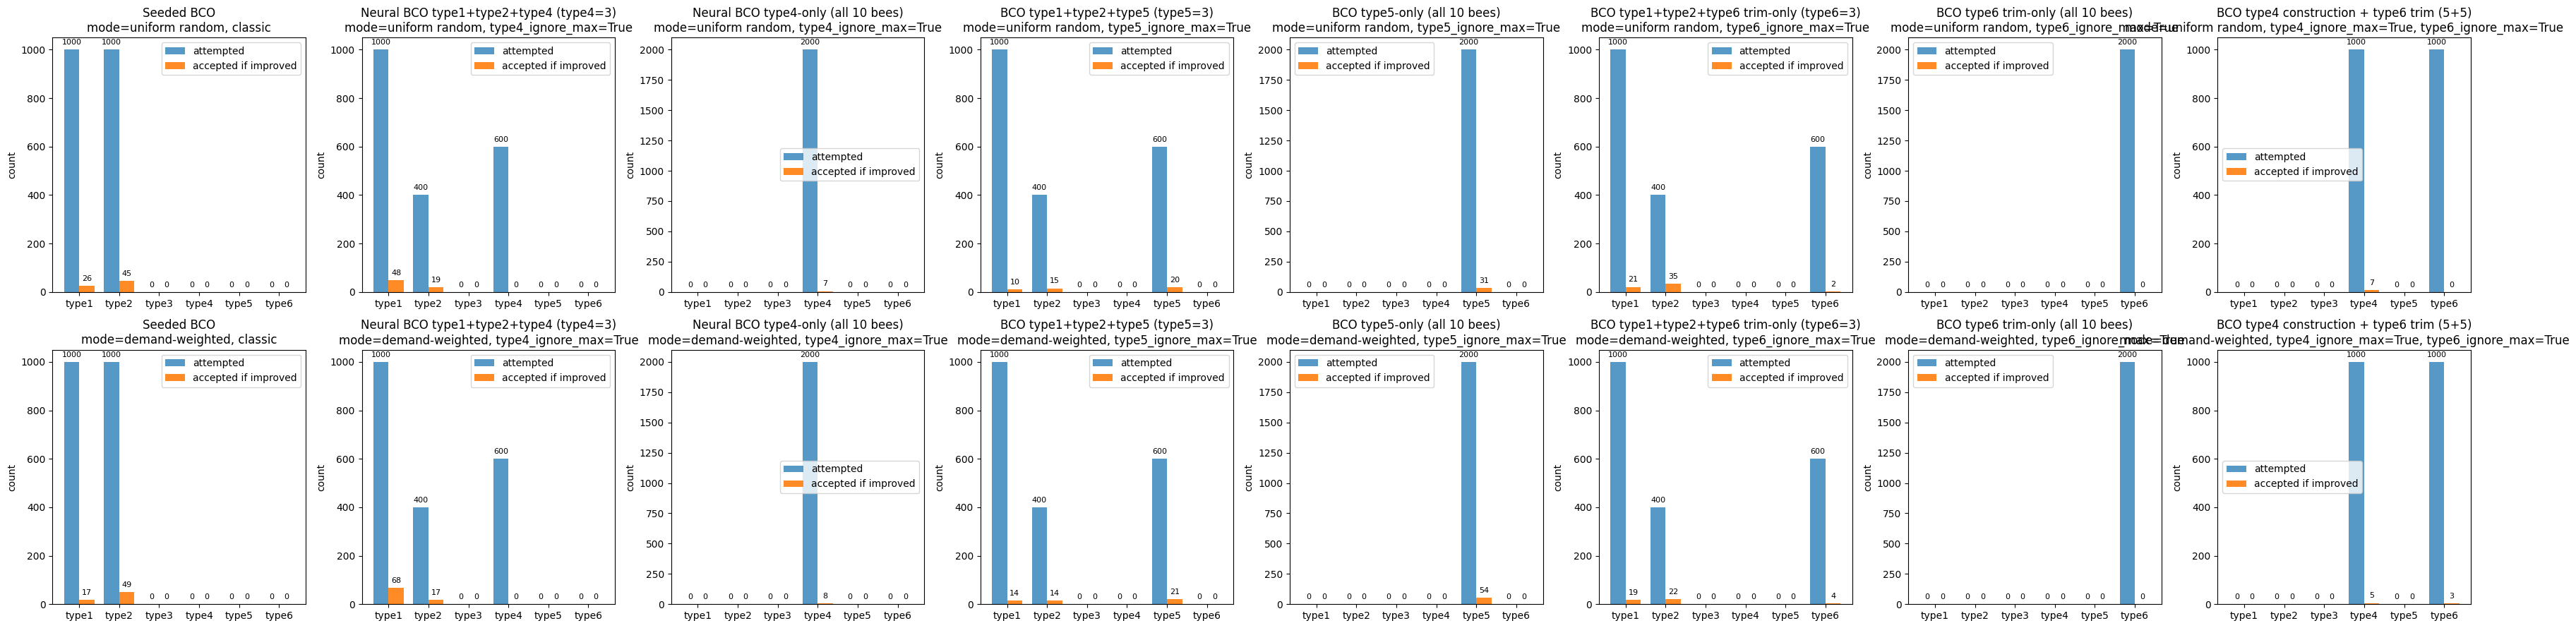

In [13]:
ensure_bco_variant_config()
bco_experiment_results = ensure_bco_experiment_results(force=False)

def plot_mutation_counts(mutation_stats: dict, title: str, ax=None):
    attempted = mutation_stat_bucket(mutation_stats, "attempted")
    accepted = mutation_stat_bucket(mutation_stats, "accepted")
    if not any(attempted.values()) and not any(accepted.values()):
        print(f"No mutation stats for '{title}'.")
        return

    show = ax is None
    if show:
        fig, ax = plt.subplots(figsize=(6.5, 4))

    labels = list(attempted.keys())
    xs = np.arange(len(labels))
    width = 0.38
    attempted_vals = [attempted[label] for label in labels]
    accepted_vals = [accepted[label] for label in labels]

    bars_attempted = ax.bar(xs - width / 2, attempted_vals, width,
                            color="tab:blue", alpha=0.75, label="attempted")
    bars_accepted = ax.bar(xs + width / 2, accepted_vals, width,
                           color="tab:orange", alpha=0.9,
                           label="accepted if improved")
    ax.set_xticks(xs)
    ax.set_xticklabels(labels)
    ax.set_title(title)
    ax.set_ylabel("count")
    ax.legend()

    ymax = max(attempted_vals + accepted_vals + [1])
    for bars in (bars_attempted, bars_accepted):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2,
                    height + ymax * 0.015,
                    f"{int(height)}",
                    ha="center", va="bottom", fontsize=8)

    if show:
        plt.tight_layout()
        plt.show()


mode_keys = list(BCO_ROUTE_SELECTION_MODES.keys())
fig, axes = plt.subplots(len(mode_keys), len(BCO_VARIANTS), figsize=(4.4 * len(BCO_VARIANTS), 4.5 * len(mode_keys)), squeeze=False)
for row_idx, mode_key in enumerate(mode_keys):
    mode_label = route_selection_mode_label(mode_key)
    for col_idx, variant in enumerate(BCO_VARIANTS):
        result = bco_experiment_results[mode_key][variant["key"]]
        ignore_bits = []
        if variant.get("n_type4_bees", 0):
            ignore_bits.append(f"type4_ignore_max={BCO_TYPE4_IGNORE_MAX_ROUTE_LEN}")
        if variant.get("n_type5_bees", 0):
            ignore_bits.append(f"type5_ignore_max={BCO_TYPE5_IGNORE_MAX_ROUTE_LEN}")
        if variant.get("n_type6_bees", 0):
            ignore_bits.append(f"type6_ignore_max={BCO_TYPE6_IGNORE_MAX_ROUTE_LEN}")
        ignore_text = ", ".join(ignore_bits) if ignore_bits else "classic"
        title = (
            f"{variant['summary_label']}\n"
            f"mode={mode_label}, {ignore_text}"
        )
        plot_mutation_counts(result["mutation_counts"], title, ax=axes[row_idx, col_idx])
plt.tight_layout()
plt.show()


## 10. GNN Route-Generation Step Statistics

How many model calls (segment predictions + halt) the GNN makes per route slot
during the LC construction phase.  Measured across all `LC_SAMPLES` forward
passes of the baseline and seeded LC runs.

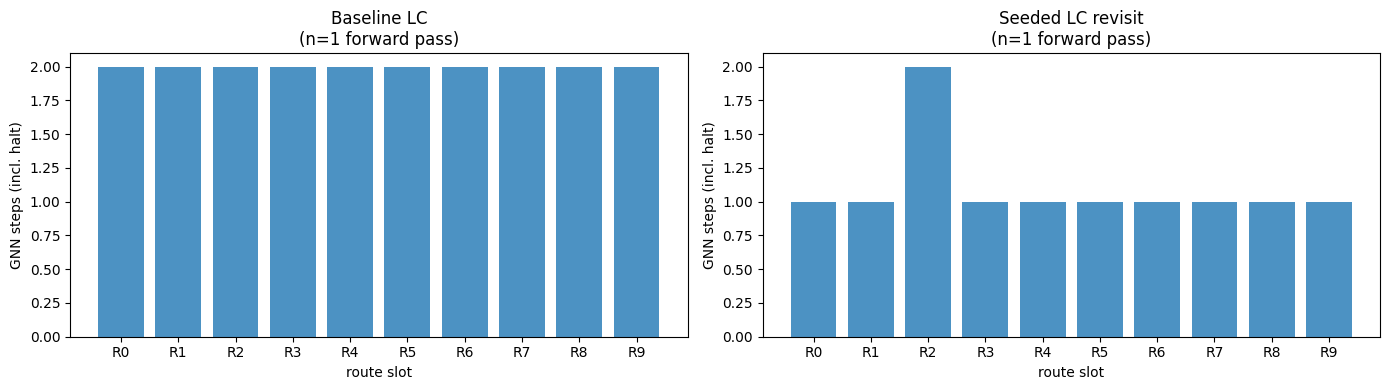

Baseline LC  — total GNN calls logged: 10, mean/route: 2.00
Seeded LC    — total GNN calls logged: 10, mean/route: 1.10


In [14]:
import numpy as np

def plot_step_counts(step_counts: list, n_routes: int, title: str, ax=None):
    """Visualise GNN calls per route slot.

    step_counts is a flat list of per-route step counts logged by the model
    (element-0 of the batch).  Each forward()/plan_new_route() call appends
    n_routes entries in route order, so the list has length k * n_routes where
    k is the number of forward passes recorded.
    """
    if not step_counts:
        print(f"No step count data for '{title}'.")
        return
    show = ax is None
    if show:
        fig, ax = plt.subplots(figsize=(7, 4))

    arr = np.array(step_counts, dtype=float)
    n_complete = (len(arr) // n_routes) * n_routes
    if n_complete == 0:
        print(f"'{title}': not enough data to reshape into {n_routes} routes "
              f"(got {len(arr)} entries).")
        return
    arr = arr[:n_complete].reshape(-1, n_routes)   # (k, n_routes)

    means = arr.mean(axis=0)
    stds  = arr.std(axis=0)
    xs = np.arange(n_routes)

    ax.bar(xs, means, yerr=stds if arr.shape[0] > 1 else None,
           capsize=4, color="tab:blue", alpha=0.8)
    ax.set_xticks(xs)
    ax.set_xticklabels([f"R{i}" for i in xs])
    ax.set_xlabel("route slot")
    ax.set_ylabel("GNN steps (incl. halt)")
    n_samples_shown = arr.shape[0]
    ax.set_title(f"{title}\n(n={n_samples_shown} forward pass{'es' if n_samples_shown > 1 else ''})")
    if show:
        plt.tight_layout()
        plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_step_counts(lc_base_step_counts,   BASE_N_ROUTES,   "Baseline LC", ax=axes[0])
plot_step_counts(lc_seeded_step_counts, SEEDED_N_ROUTES, "Seeded LC revisit", ax=axes[1])
plt.tight_layout()
plt.show()

if lc_base_step_counts:
    print(f"Baseline LC  — total GNN calls logged: {len(lc_base_step_counts)}, "
          f"mean/route: {np.mean(lc_base_step_counts):.2f}")
if lc_seeded_step_counts:
    print(f"Seeded LC    — total GNN calls logged: {len(lc_seeded_step_counts)}, "
          f"mean/route: {np.mean(lc_seeded_step_counts):.2f}")


In [15]:
from IPython.display import display

ensure_lc_base(force=False)
ensure_lc_seeded(force=False)
ensure_bco_experiment_results(force=False)

comparison_rows = [
    {
        **summarize_run("Baseline LC", lc_base_metrics, lc_base_routes),
        "route_selection": "n/a",
        "variant": "Baseline LC",
    },
    {
        **summarize_run("Seeded LC", lc_seeded_metrics, lc_seeded_routes),
        "route_selection": "n/a",
        "variant": "Seeded LC",
    },
]

mutation_rows = []

for mode_key, mode_cfg in BCO_ROUTE_SELECTION_MODES.items():
    for variant in BCO_VARIANTS:
        result = bco_experiment_results[mode_key][variant["key"]]
        row = summarize_run(
            f"{variant['summary_label']} [{mode_cfg['label']}]",
            result["metrics"],
            result["routes_tensor"],
        )
        row["route_selection"] = mode_cfg["label"]
        row["variant"] = variant["summary_label"]
        comparison_rows.append(row)

        attempted = mutation_stat_bucket(result["mutation_counts"], "attempted")
        accepted = mutation_stat_bucket(result["mutation_counts"], "accepted")
        type2_bees = variant["n_type2_bees"]
        if type2_bees is None:
            type2_bees = (
                BCO_N_BEES - variant["n_type1_bees"] -
                variant["n_type4_bees"] - variant.get("n_type5_bees", 0) -
                variant.get("n_type6_bees", 0)
            )
        mutation_rows.append({
            "route_selection": mode_cfg["label"],
            "variant": variant["summary_label"],
            "type1_bees": variant["n_type1_bees"],
            "type2_bees": type2_bees,
            "type4_bees": variant["n_type4_bees"],
            "type5_bees": variant.get("n_type5_bees", 0),
            "type6_bees": variant.get("n_type6_bees", 0),
            "attempted_type1": attempted["type1"],
            "attempted_type2": attempted["type2"],
            "attempted_type3": attempted["type3"],
            "attempted_type4": attempted["type4"],
            "attempted_type5": attempted["type5"],
            "attempted_type6": attempted["type6"],
            "accepted_type1": accepted["type1"],
            "accepted_type2": accepted["type2"],
            "accepted_type3": accepted["type3"],
            "accepted_type4": accepted["type4"],
            "accepted_type5": accepted["type5"],
            "accepted_type6": accepted["type6"],
        })

comparison_df = pd.DataFrame(comparison_rows)
seeded_lc_row = comparison_df.loc[comparison_df["method"] == "Seeded LC"].iloc[0]
comparison_df["delta_cost_vs_seeded_lc"] = comparison_df["cost"] - seeded_lc_row["cost"]
comparison_df["delta_ATT_vs_seeded_lc"] = comparison_df["ATT"] - seeded_lc_row["ATT"]
comparison_df["delta_RTT_vs_seeded_lc"] = comparison_df["RTT"] - seeded_lc_row["RTT"]
comparison_df = comparison_df[[
    "method",
    "route_selection",
    "variant",
    "cost",
    "ATT",
    "RTT",
    "$d_{un}$",
    "# routes",
    "delta_cost_vs_seeded_lc",
    "delta_ATT_vs_seeded_lc",
    "delta_RTT_vs_seeded_lc",
]]
bco_mutation_comparison_df = pd.DataFrame(mutation_rows)

display(comparison_df.round(4))
display(bco_mutation_comparison_df)


,method,route_selection,variant,cost,ATT,RTT,$d_{un}$,# routes,delta_cost_vs_seeded_lc,delta_ATT_vs_seeded_lc,delta_RTT_vs_seeded_lc
0,Baseline LC,n/a,Baseline LC,3.8993,24.8841,180.0,64.2916,10,0.7475,0.6348,-48.0
1,Seeded LC,n/a,Seeded LC,3.1518,24.2494,228.0,49.1758,10,0.0000,0.0000,0.0
2,Seeded BCO [uniform random],uniform random,Seeded BCO,0.7149,23.2342,256.0,1.4292,10,-2.4369,-1.0152,28.0
3,Neural BCO type1+type2+type4 (type4=3) [unifor...,uniform random,Neural BCO type1+type2+type4 (type4=3),0.7032,21.2333,270.0,0.4442,10,-2.4486,-3.0161,42.0
4,Neural BCO type4-only (all 10 bees) [uniform r...,uniform random,Neural BCO type4-only (all 10 bees),0.7779,23.1071,306.0,4.4804,10,-2.3739,-1.1423,78.0
5,BCO type1+type2+type5 (type5=3) [uniform random],uniform random,BCO type1+type2+type5 (type5=3),0.7962,22.3551,330.0,5.0152,10,-2.3556,-1.8942,102.0
6,BCO type5-only (all 10 bees) [uniform random],uniform random,BCO type5-only (all 10 bees),0.7961,20.7266,348.0,0.0000,10,-2.3557,-3.5228,120.0
7,BCO type1+type2+type6 trim-only (type6=3) [uni...,uniform random,BCO type1+type2+type6 trim-only (type6=3),0.7473,22.9602,284.0,3.8140,10,-2.4045,-1.2892,56.0
8,BCO type6 trim-only (all 10 bees) [uniform ran...,uniform random,BCO type6 trim-only (all 10 bees),3.8993,24.8841,180.0,64.2916,10,0.7475,0.6348,-48.0
9,BCO type4 construction + type6 trim (5+5) [uni...,uniform random,BCO type4 construction + type6 trim (5+5),1.6170,23.4252,292.0,17.5210,10,-1.5348,-0.8241,64.0


,route_selection,variant,type1_bees,type2_bees,type4_bees,type5_bees,type6_bees,attempted_type1,attempted_type2,attempted_type3,attempted_type4,attempted_type5,attempted_type6,accepted_type1,accepted_type2,accepted_type3,accepted_type4,accepted_type5,accepted_type6
0,uniform random,Seeded BCO,5,5,0,0,0,1000,1000,0,0,0,0,26,45,0,0,0,0
1,uniform random,Neural BCO type1+type2+type4 (type4=3),5,2,3,0,0,1000,400,0,600,0,0,48,19,0,0,0,0
2,uniform random,Neural BCO type4-only (all 10 bees),0,0,10,0,0,0,0,0,2000,0,0,0,0,0,7,0,0
3,uniform random,BCO type1+type2+type5 (type5=3),5,2,0,3,0,1000,400,0,0,600,0,10,15,0,0,20,0
4,uniform random,BCO type5-only (all 10 bees),0,0,0,10,0,0,0,0,0,2000,0,0,0,0,0,31,0
5,uniform random,BCO type1+type2+type6 trim-only (type6=3),5,2,0,0,3,1000,400,0,0,0,600,21,35,0,0,0,2
6,uniform random,BCO type6 trim-only (all 10 bees),0,0,0,0,10,0,0,0,0,0,2000,0,0,0,0,0,0
7,uniform random,BCO type4 construction + type6 trim (5+5),0,0,5,0,5,0,0,0,1000,0,1000,0,0,0,7,0,0
8,demand-weighted,Seeded BCO,5,5,0,0,0,1000,1000,0,0,0,0,17,49,0,0,0,0
9,demand-weighted,Neural BCO type1+type2+type4 (type4=3),5,2,3,0,0,1000,400,0,600,0,0,68,17,0,0,0,0


## 9. Route Change Visualization

The baseline LC solution is used as the reference. Each row corresponds to one route-selection mode (`uniform random` vs `demand-weighted`), and the seeded LC / BCO variants are shown as diffs relative to that initial LC network.


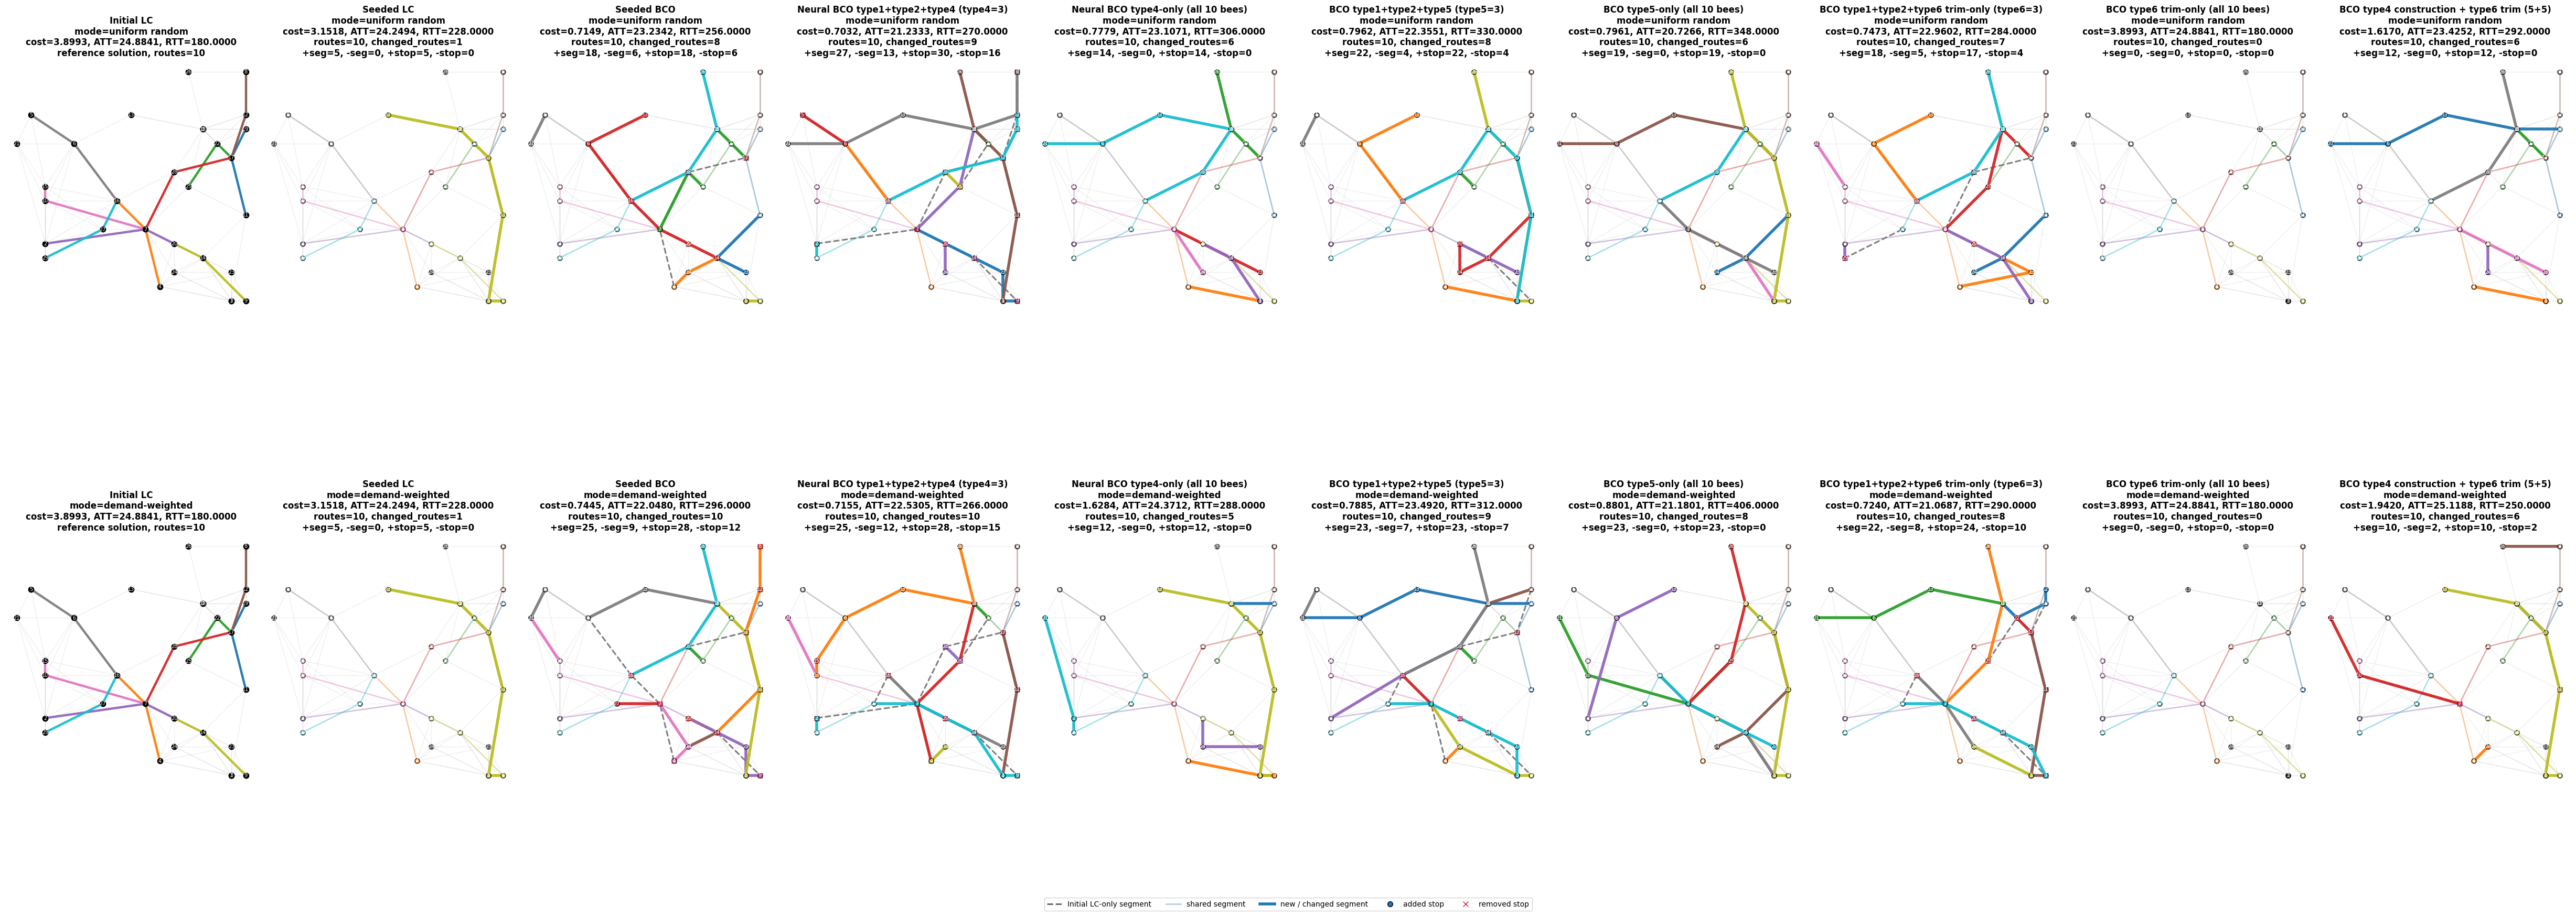

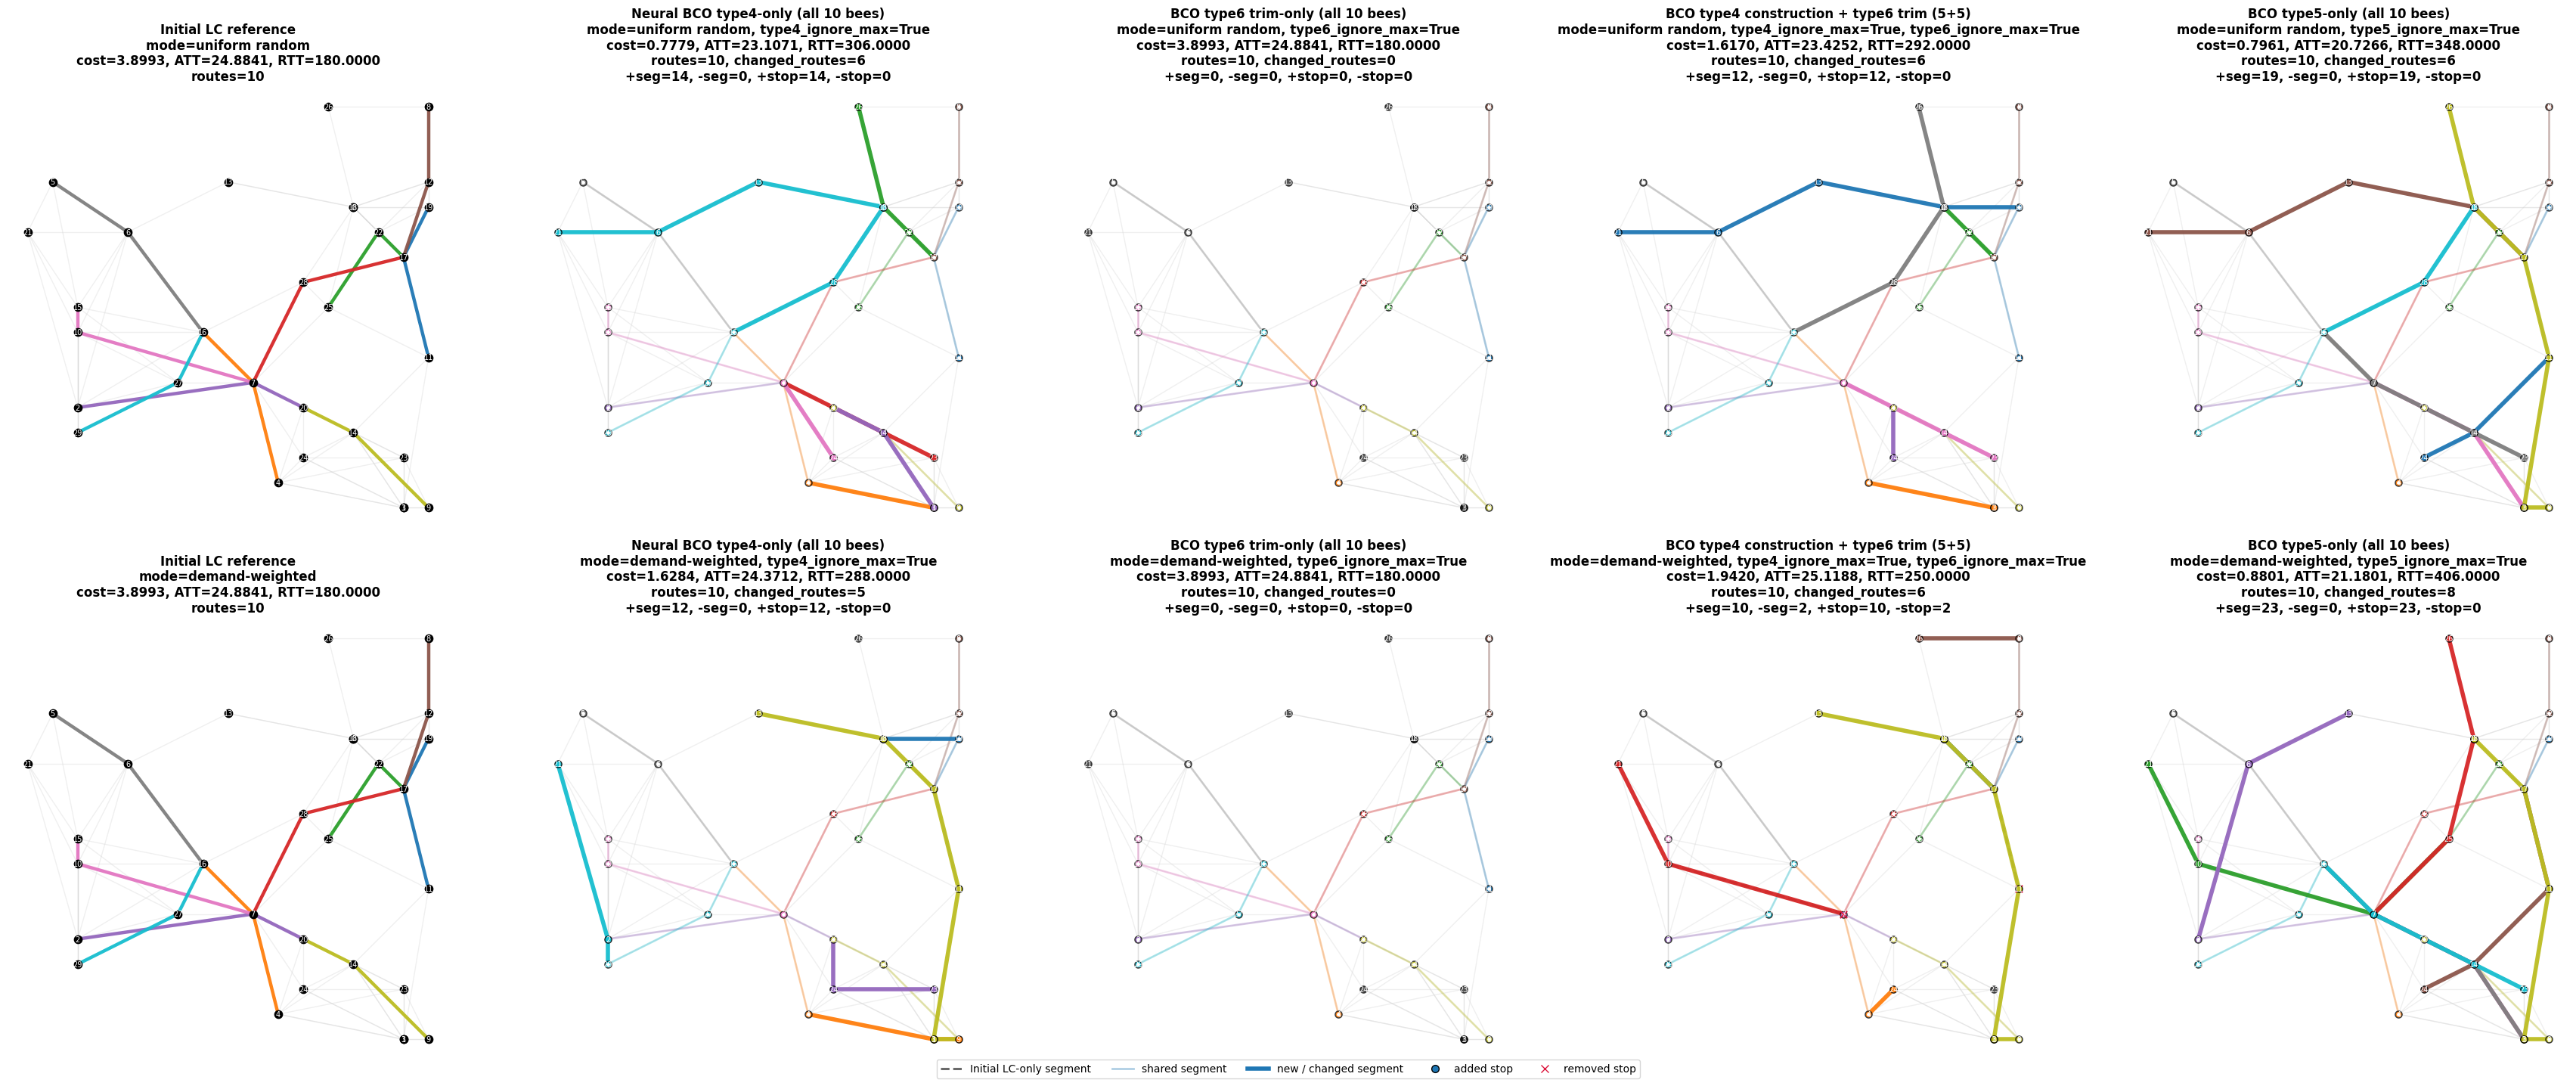

In [16]:
ensure_input_tensors(force=False)
ensure_lc_base(force=False)
ensure_lc_seeded(force=False)
ensure_bco_experiment_results(force=False)


from matplotlib.lines import Line2D


def as_route_tensor(routes):
    if isinstance(routes, torch.Tensor):
        return routes.detach().cpu()
    return get_batch_tensor_from_routes(routes).detach().cpu()


def get_first_route_set(routes):
    routes = as_route_tensor(routes)
    if routes.ndim == 3:
        return routes[0]
    return routes


def route_to_list(route_tensor):
    return [int(x) for x in route_tensor.tolist() if x != -1]


def route_edge_list(route):
    return [(route[i], route[i + 1]) for i in range(len(route) - 1)]


def undirected_edge_key(edge):
    u, v = edge
    return tuple(sorted((u, v)))


def draw_street_graph(ax, coords, street_adj):
    n_nodes = coords.shape[0]
    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            if np.isfinite(street_adj[i, j]) or np.isfinite(street_adj[j, i]):
                ax.plot(
                    [coords[i, 0], coords[j, 0]],
                    [coords[i, 1], coords[j, 1]],
                    color="lightgray",
                    linewidth=1.0,
                    alpha=0.35,
                    zorder=1,
                )


def plot_edges(ax, coords, edges, *, color, linewidth, alpha, linestyle="-", zorder=3):
    for u, v in edges:
        ax.plot(
            [coords[u, 0], coords[v, 0]],
            [coords[u, 1], coords[v, 1]],
            color=color,
            linewidth=linewidth,
            alpha=alpha,
            linestyle=linestyle,
            solid_capstyle="round",
            zorder=zorder,
        )


def summarize_route_changes(routes, reference_routes):
    routes = get_first_route_set(routes)
    reference_routes = get_first_route_set(reference_routes)
    n_routes = max(routes.shape[0], reference_routes.shape[0])
    summary = {
        "changed_routes": 0,
        "added_edges": 0,
        "removed_edges": 0,
        "added_stops": 0,
        "removed_stops": 0,
    }

    for idx in range(n_routes):
        route = route_to_list(routes[idx]) if idx < routes.shape[0] else []
        reference = route_to_list(reference_routes[idx]) if idx < reference_routes.shape[0] else []

        route_edges = {undirected_edge_key(edge) for edge in route_edge_list(route)}
        reference_edges = {undirected_edge_key(edge) for edge in route_edge_list(reference)}
        route_nodes = set(route)
        reference_nodes = set(reference)

        added_edges = route_edges - reference_edges
        removed_edges = reference_edges - route_edges
        added_stops = route_nodes - reference_nodes
        removed_stops = reference_nodes - route_nodes

        if added_edges or removed_edges or added_stops or removed_stops:
            summary["changed_routes"] += 1
        summary["added_edges"] += len(added_edges)
        summary["removed_edges"] += len(removed_edges)
        summary["added_stops"] += len(added_stops)
        summary["removed_stops"] += len(removed_stops)

    return summary


def plot_plain_route_set(ax, routes, coords, street_adj, title, subtitle=None):
    routes = get_first_route_set(routes)
    coords = coords.detach().cpu().numpy() if isinstance(coords, torch.Tensor) else np.asarray(coords)
    street_adj = street_adj.detach().cpu().numpy() if isinstance(street_adj, torch.Tensor) else np.asarray(street_adj)
    draw_street_graph(ax, coords, street_adj)

    colors = plt.cm.tab10(np.linspace(0, 1, max(10, routes.shape[0])))
    for idx, route_tensor in enumerate(routes):
        route = route_to_list(route_tensor)
        if len(route) < 2:
            continue
        color = colors[idx % len(colors)]
        plot_edges(
            ax,
            coords,
            route_edge_list(route),
            color=color,
            linewidth=3.2,
            alpha=0.95,
            zorder=3,
        )

    ax.scatter(coords[:, 0], coords[:, 1], c="black", s=55, zorder=5)
    for node_idx, (x, y) in enumerate(coords):
        ax.text(x, y, str(node_idx), fontsize=7, color="white", ha="center", va="center", zorder=6)

    ax.set_title(f"{title}\n{subtitle}" if subtitle else title, fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")


def plot_route_diff(ax, routes, reference_routes, coords, street_adj, title, subtitle=None):
    routes = get_first_route_set(routes)
    reference_routes = get_first_route_set(reference_routes)
    coords = coords.detach().cpu().numpy() if isinstance(coords, torch.Tensor) else np.asarray(coords)
    street_adj = street_adj.detach().cpu().numpy() if isinstance(street_adj, torch.Tensor) else np.asarray(street_adj)
    draw_street_graph(ax, coords, street_adj)

    colors = plt.cm.tab10(np.linspace(0, 1, max(10, max(routes.shape[0], reference_routes.shape[0]))))
    n_routes = max(routes.shape[0], reference_routes.shape[0])

    for idx in range(n_routes):
        route = route_to_list(routes[idx]) if idx < routes.shape[0] else []
        reference = route_to_list(reference_routes[idx]) if idx < reference_routes.shape[0] else []
        color = colors[idx % len(colors)]

        route_edges_in_order = route_edge_list(route)
        reference_edges_in_order = route_edge_list(reference)
        route_edge_keys = {undirected_edge_key(edge) for edge in route_edges_in_order}
        reference_edge_keys = {undirected_edge_key(edge) for edge in reference_edges_in_order}

        shared_edges = [edge for edge in route_edges_in_order if undirected_edge_key(edge) in reference_edge_keys]
        added_edges = [edge for edge in route_edges_in_order if undirected_edge_key(edge) not in reference_edge_keys]
        removed_edges = [edge for edge in reference_edges_in_order if undirected_edge_key(edge) not in route_edge_keys]

        if removed_edges:
            plot_edges(
                ax,
                coords,
                removed_edges,
                color="dimgray",
                linewidth=2.2,
                alpha=0.85,
                linestyle="--",
                zorder=2,
            )
        if shared_edges:
            plot_edges(
                ax,
                coords,
                shared_edges,
                color=color,
                linewidth=2.0,
                alpha=0.35,
                zorder=3,
            )
        if added_edges:
            plot_edges(
                ax,
                coords,
                added_edges,
                color=color,
                linewidth=4.0,
                alpha=0.95,
                zorder=4,
            )

        route_nodes = set(route)
        reference_nodes = set(reference)
        shared_nodes = sorted(route_nodes & reference_nodes)
        added_nodes = sorted(route_nodes - reference_nodes)
        removed_nodes = sorted(reference_nodes - route_nodes)

        if shared_nodes:
            ax.scatter(coords[shared_nodes, 0], coords[shared_nodes, 1], s=20, facecolors="white", edgecolors=[color], linewidths=1.0, zorder=5)
        if added_nodes:
            ax.scatter(coords[added_nodes, 0], coords[added_nodes, 1], s=40, c=[color], edgecolors="black", linewidths=0.5, zorder=6)
        if removed_nodes:
            ax.scatter(coords[removed_nodes, 0], coords[removed_nodes, 1], s=45, c="crimson", marker="x", linewidths=1.4, zorder=6)

    ax.scatter(coords[:, 0], coords[:, 1], c="black", s=45, alpha=0.65, zorder=4)
    for node_idx, (x, y) in enumerate(coords):
        ax.text(x, y, str(node_idx), fontsize=7, color="white", ha="center", va="center", zorder=7)

    ax.set_title(f"{title}\n{subtitle}" if subtitle else title, fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")


def metric_value(metrics, key):
    value = metrics[key]
    if isinstance(value, torch.Tensor):
        return float(value.squeeze().item())
    return float(value)


coords = input_tensors["node_locs"]
street_adj = input_tensors["street_adj"]
mode_keys = list(BCO_ROUTE_SELECTION_MODES.keys())

n_comparison_cols = 2 + len(BCO_VARIANTS)
fig, axes = plt.subplots(len(mode_keys), n_comparison_cols, figsize=(4.9 * n_comparison_cols, 9 * len(mode_keys)), squeeze=False, constrained_layout=True)
for row_idx, mode_key in enumerate(mode_keys):
    mode_label = route_selection_mode_label(mode_key)
    mode_results = bco_experiment_results[mode_key]
    comparison_rows = [
        {
            "label": f"Initial LC\nmode={mode_label}",
            "routes": lc_base_routes,
            "metrics": lc_base_metrics,
            "is_reference": True,
        },
        {
            "label": f"Seeded LC\nmode={mode_label}",
            "routes": lc_seeded_routes,
            "metrics": lc_seeded_metrics,
            "is_reference": False,
        },
    ]
    for variant in BCO_VARIANTS:
        result = mode_results[variant["key"]]
        comparison_rows.append({
            "label": f"{variant['summary_label']}\nmode={mode_label}",
            "routes": result["routes_tensor"],
            "metrics": result["metrics"],
            "is_reference": False,
        })
    reference_row = comparison_rows[0]

    for ax, row in zip(axes[row_idx], comparison_rows):
        if row["is_reference"]:
            ref_routes = get_first_route_set(row["routes"])
            n_nonempty_routes = int(((ref_routes > -1).sum(dim=-1) > 1).sum().item())
            subtitle = (
                f"cost={metric_value(row['metrics'], 'cost'):.4f}, ATT={metric_value(row['metrics'], 'ATT'):.4f}, RTT={metric_value(row['metrics'], 'RTT'):.4f}"
                f"\nreference solution, routes={n_nonempty_routes}"
            )
            plot_plain_route_set(ax, row["routes"], coords, street_adj, row["label"], subtitle)
            continue

        change_summary = summarize_route_changes(row["routes"], reference_row["routes"])
        compared_routes = get_first_route_set(row["routes"])
        n_nonempty_routes = int(((compared_routes > -1).sum(dim=-1) > 1).sum().item())
        subtitle = (
            f"cost={metric_value(row['metrics'], 'cost'):.4f}, ATT={metric_value(row['metrics'], 'ATT'):.4f}, RTT={metric_value(row['metrics'], 'RTT'):.4f}"
            f"\nroutes={n_nonempty_routes}, changed_routes={change_summary['changed_routes']}"
            f"\n+seg={change_summary['added_edges']}, -seg={change_summary['removed_edges']}, +stop={change_summary['added_stops']}, -stop={change_summary['removed_stops']}"
        )
        plot_route_diff(ax, row["routes"], reference_row["routes"], coords, street_adj, row["label"], subtitle)

style_handles = [
    Line2D([0], [0], color="dimgray", lw=2.2, linestyle="--", label="Initial LC-only segment"),
    Line2D([0], [0], color="tab:blue", lw=2.0, alpha=0.35, label="shared segment"),
    Line2D([0], [0], color="tab:blue", lw=4.0, label="new / changed segment"),
    Line2D([0], [0], marker="o", color="black", markerfacecolor="tab:blue", markersize=7, lw=0, label="added stop"),
    Line2D([0], [0], marker="x", color="crimson", markersize=7, lw=0, label="removed stop"),
]
fig.legend(handles=style_handles, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=5, frameon=True)
plt.show()

focus_variant_keys = ["type4_only", "type6_only", "type4_type6_split", "type5_only"]
focus_cols = 1 + len(focus_variant_keys)
fig, axes = plt.subplots(len(mode_keys), focus_cols, figsize=(7 * focus_cols, 7 * len(mode_keys)), squeeze=False, constrained_layout=True)
for row_idx, mode_key in enumerate(mode_keys):
    mode_label = route_selection_mode_label(mode_key)
    reference_routes = get_first_route_set(lc_base_routes)
    reference_nonempty = int(((reference_routes > -1).sum(dim=-1) > 1).sum().item())
    plot_plain_route_set(
        axes[row_idx, 0],
        lc_base_routes,
        coords,
        street_adj,
        f"Initial LC reference\nmode={mode_label}",
        subtitle=(
            f"cost={metric_value(lc_base_metrics, 'cost'):.4f}, "
            f"ATT={metric_value(lc_base_metrics, 'ATT'):.4f}, "
            f"RTT={metric_value(lc_base_metrics, 'RTT'):.4f}\n"
            f"routes={reference_nonempty}"
        ),
    )

    for col_idx, variant_key in enumerate(focus_variant_keys, start=1):
        result = bco_experiment_results[mode_key][variant_key]
        change_summary = summarize_route_changes(result["routes_tensor"], lc_base_routes)
        result_routes = get_first_route_set(result["routes_tensor"])
        result_nonempty = int(((result_routes > -1).sum(dim=-1) > 1).sum().item())
        ignore_bits = []
        if result.get("n_type4_bees", 0):
            ignore_bits.append(f"type4_ignore_max={BCO_TYPE4_IGNORE_MAX_ROUTE_LEN}")
        if result.get("n_type5_bees", 0):
            ignore_bits.append(f"type5_ignore_max={BCO_TYPE5_IGNORE_MAX_ROUTE_LEN}")
        if result.get("n_type6_bees", 0):
            ignore_bits.append(f"type6_ignore_max={BCO_TYPE6_IGNORE_MAX_ROUTE_LEN}")
        ignore_text = ", ".join(ignore_bits)
        plot_route_diff(
            axes[row_idx, col_idx],
            result["routes_tensor"],
            lc_base_routes,
            coords,
            street_adj,
            f"{result['variant_label']}\nmode={mode_label}, {ignore_text}",
            subtitle=(
                f"cost={metric_value(result['metrics'], 'cost'):.4f}, "
                f"ATT={metric_value(result['metrics'], 'ATT'):.4f}, "
                f"RTT={metric_value(result['metrics'], 'RTT'):.4f}\n"
                f"routes={result_nonempty}, "
                f"changed_routes={change_summary['changed_routes']}\n"
                f"+seg={change_summary['added_edges']}, "
                f"-seg={change_summary['removed_edges']}, "
                f"+stop={change_summary['added_stops']}, "
                f"-stop={change_summary['removed_stops']}"
            ),
        )

focus_handles = [
    Line2D([0], [0], color="dimgray", lw=2.2, linestyle="--", label="Initial LC-only segment"),
    Line2D([0], [0], color="tab:blue", lw=2.0, alpha=0.35, label="shared segment"),
    Line2D([0], [0], color="tab:blue", lw=4.0, label="new / changed segment"),
    Line2D([0], [0], marker="o", color="black", markerfacecolor="tab:blue", markersize=7, lw=0, label="added stop"),
    Line2D([0], [0], marker="x", color="crimson", markersize=7, lw=0, label="removed stop"),
]
fig.legend(handles=focus_handles, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=5, frameon=True)
plt.show()
